# OMI Residential Real Estate Quotations — Exploratory & Trend Analysis

This notebook builds a reproducible, statistically grounded exploration of the semiannual
**OMI (Osservatorio del Mercato Immobiliare)** real estate quotations published by the
Italian *Agenzia delle Entrate*. It moves from raw schema inspection to a full price
trend, growth and risk analysis at national, regional, provincial, municipal and
intra-municipal ("zone") granularity, with a dedicated focus on the Lombardy region and
the Province of Brescia.

**Source:** Agenzia delle Entrate — Osservatorio del Mercato Immobiliare (OMI), semiannual
quotation releases.

**Scope:** residential purchase ("compravendita") quotations, expressed in €/m² as the
midpoint of the OMI minimum/maximum range (`Compr_mid`).

## Contents

1. Setup
2. Data Loading
3. Initial Data Inspection
4. Property Type Overview
5. Residential Subset Construction
6. Price Trend Analysis — national, regional, provincial, municipal, zone
7. Regional Focus: Lombardy & Brescia
8. Growth & Risk Analytics
9. Key Insights & Limitations

> **Methodological note.** Rankings based on growth rates (CAGR, volatility, drawdown,
> YoY growth) are restricted to series with a minimum amount of history (`MIN_PERIODS`,
> set in Section 8.1). Very short series produce extreme, noisy growth figures that are
> not statistically meaningful, so they are excluded from "top/bottom" tables rather
> than silently distorting them.


## 1. Setup

The analytical stack is kept lightweight on purpose: `pandas` for data preparation,
`numpy` for numerical transformations and `matplotlib` for visualization. The project
root is resolved relative to the notebook's working directory so the code does not
depend on where the notebook happens to be launched from.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'quotations'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'


## 2. Data Loading

Each semiannual OMI release is originally distributed as one semicolon-separated CSV per
semester. Consolidating the individual raw releases into a single, typed, analysis-ready
table — with an explicit `reference_date` attached to every semester — is handled
upstream by the ingestion pipeline and persisted as a Parquet file. Keeping that step
separate keeps the consolidation logic independently testable and lets this notebook
focus purely on exploration.

This notebook therefore loads the already-consolidated dataset directly.


In [2]:
omi = pd.read_parquet(PROCESSED_DIR / "omi_quotations.parquet")

print(f"Rows loaded:    {omi.shape[0]:,}")
print(f"Columns loaded: {omi.shape[1]}")
omi.head()


Rows loaded:    7,516,495
Columns loaded: 31


,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,...,reference_year,reference_semester,reference_period,reference_date,Compr_mid,Loc_mid,Compr_spread,Loc_spread,Compr_spread_pct,Loc_spread_pct
0,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,395.0,NaN,150.0,NaN,37.974684,NaN
1,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,325.0,1.0,130.0,NaN,40.000000,NaN
2,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,325.0,1.0,130.0,NaN,40.000000,NaN
3,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,210.0,1.0,80.0,NaN,38.095238,NaN
4,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,85.0,NaN,30.0,NaN,35.294118,NaN


## 3. Initial Data Inspection

Before transforming any value, we inspect the schema, data types, missing values and
temporal coverage of the raw table. This step surfaces data-quality issues early and
documents the assumptions the rest of the notebook relies on.


### 3.1 Schema and Data Quality

In [3]:
omi.info()


<class 'pandas.DataFrame'>
RangeIndex: 7516495 entries, 0 to 7516494
Data columns (total 31 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Area_territoriale   str           
 1   Regione             str           
 2   Prov                str           
 3   Comune_ISTAT        float64       
 4   Comune_cat          str           
 5   Sez                 str           
 6   Comune_amm          str           
 7   Comune_descrizione  str           
 8   Fascia              str           
 9   Zona                str           
 10  LinkZona            str           
 11  Cod_Tip             int64         
 12  Descr_Tipologia     str           
 13  Stato               str           
 14  Stato_prev          str           
 15  Compr_min           float64       
 16  Compr_max           float64       
 17  Sup_NL_compr        str           
 18  Loc_min             float64       
 19  Loc_max             float64       
 20  Sup_NL_loc   

In [4]:
missing_share = (
    omi.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_share = missing_share[missing_share > 0]

if missing_share.empty:
    print("No missing values detected in any column.")
else:
    display(missing_share.to_frame('missing_%').style.format('{:.2f}%'))


,missing_%
Sez,99.95%
Loc_spread_pct,95.68%
Loc_spread,95.16%
Loc_max,85.47%
Loc_min,85.34%
Loc_mid,75.65%
Stato_prev,9.66%
Sup_NL_loc,7.48%
Prov,2.05%
Stato,1.28%


### 3.2 Temporal and Categorical Coverage

In [5]:
print(f"Reference period range: {omi['reference_date'].min().date()} → {omi['reference_date'].max().date()}")
print(f"Number of semesters covered: {omi['reference_date'].nunique()}")
print(f"Regions: {omi['Regione'].nunique()}  |  Provinces: {omi['Prov'].nunique()}  |  Municipalities: {omi['Comune_descrizione'].nunique()}")


Reference period range: 2004-06-30 → 2025-12-31
Number of semesters covered: 44
Regions: 20  |  Provinces: 102  |  Municipalities: 8220


## 4. Property Type Overview

`Descr_Tipologia` classifies each OMI observation by real estate typology (residential,
commercial, industrial, agricultural, etc.). Before narrowing the analysis to
residential quotations, we look at how observations are distributed across all
typologies, to confirm residential categories are indeed the dominant segment of the
dataset.


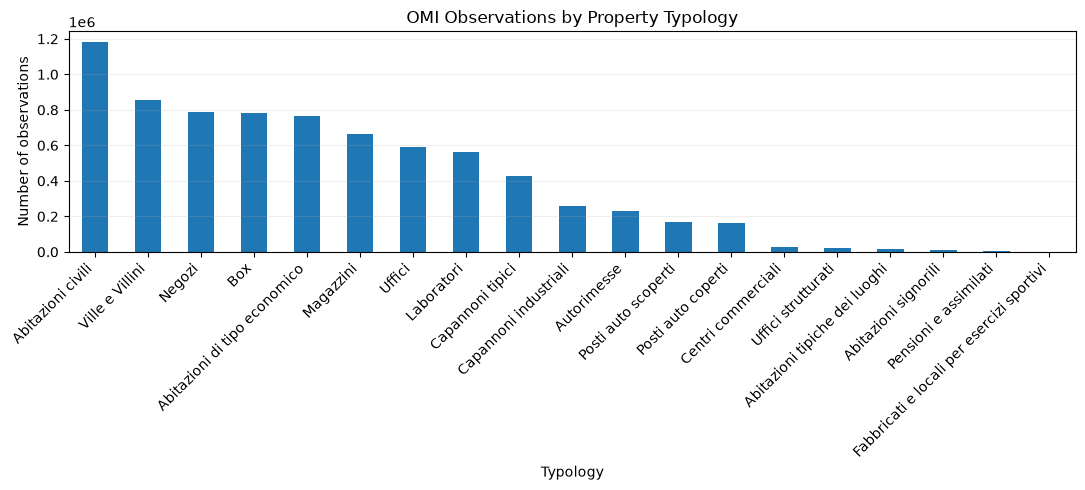

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

omi['Descr_Tipologia'].value_counts().plot(kind='bar', ax=ax)

ax.set_title('OMI Observations by Property Typology')
ax.set_xlabel('Typology')
ax.set_ylabel('Number of observations')
ax.grid(axis='y', alpha=0.2)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.tight_layout()
plt.show()


## 5. Residential Subset Construction

The rest of the notebook focuses on residential purchase quotations. Residential
typologies are identified with a case-insensitive match on `Descr_Tipologia` against the
Italian terms `abitazion` (covers "Abitazioni civili", "Abitazioni di tipo economico",
"Abitazioni signorili", etc.) and `villa` (covers "Ville e villini"). To confirm the
filter captures the intended categories — and nothing unintended — we print the distinct
typologies it matches before using it.


In [7]:
residential_mask = omi['Descr_Tipologia'].astype('string').str.contains(
    'abitazion|villa', case=False, na=False
)

print("Typologies captured by the residential filter:")
display(omi.loc[residential_mask, 'Descr_Tipologia'].value_counts())

residential = omi.loc[residential_mask].copy()
print(f"\nResidential observations: {len(residential):,} ({len(residential) / len(omi):.1%} of the full dataset)")


Typologies captured by the residential filter:


Descr_Tipologia
Abitazioni civili                1183089
Abitazioni di tipo economico      765963
Abitazioni tipiche dei luoghi      14287
Abitazioni signorili                8355
Name: count, dtype: int64


Residential observations: 1,971,694 (26.2% of the full dataset)


## 6. Price Trend Analysis

This section tracks the median OMI residential purchase quotation (`Compr_mid`) over
time, at progressively finer levels of geographical granularity: national, regional,
provincial, municipal and intra-municipal zone. The median is used as the primary
central-tendency statistic throughout, since OMI quotations are strictly positive and
right-skewed (a small number of very high-value urban zones), which makes the median
more robust than the mean to that skew; the mean is kept alongside it for reference.


### 6.1 National Trend

In [8]:
national_trend = (
    residential
    .groupby('reference_date', as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

display(national_trend.tail(10))


,reference_date,median_compr_mid,mean_compr_mid,observations
34,2021-06-30,900.0,1087.043634,44323
35,2021-12-31,900.0,1084.901347,44550
36,2022-06-30,895.0,1086.832873,44568
37,2022-12-31,895.0,1091.734147,44581
38,2023-06-30,895.0,1096.249776,44622
39,2023-12-31,895.0,1099.863701,44663
40,2024-06-30,890.0,1102.279793,44583
41,2024-12-31,890.0,1107.890620,44327
42,2025-06-30,900.0,1115.333657,44342
43,2025-12-31,900.0,1124.300717,44349


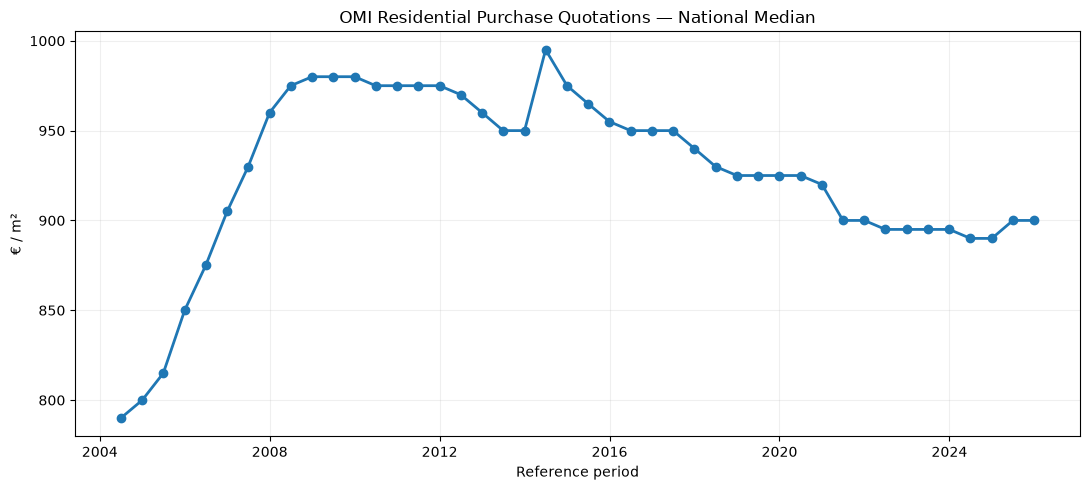

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(national_trend['reference_date'], national_trend['median_compr_mid'], marker='o', linewidth=2)

ax.set_title('OMI Residential Purchase Quotations — National Median')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()


> **Interpretation.** A rising line indicates broad national appreciation of
> residential values over the observed semesters; a flattening or declining line
> indicates stagnation or correction. Because this is a median across every province and
> zone in Italy, it smooths out strong local dynamics — those are examined in the
> regional, provincial and municipal breakdowns below, where price levels vary far more
> than this national aggregate suggests.


### 6.2 Regional Analysis

In [10]:
regional_trend = (
    residential
    .groupby(['reference_date', 'Regione'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = regional_trend['reference_date'].max()

display(regional_trend.tail(10))


,reference_date,Regione,median_compr_mid,mean_compr_mid,observations
870,2025-12-31,MOLISE,425.00,504.259962,527
871,2025-12-31,PIEMONTE,765.00,890.331683,4545
872,2025-12-31,PUGLIA,765.00,900.528933,1659
873,2025-12-31,SARDEGNA,725.00,997.329218,1215
874,2025-12-31,SICILIA,571.25,667.302383,2644
875,2025-12-31,TOSCANA,1250.00,1431.282051,1911
876,2025-12-31,TRENTINO-ALTO ADIGE,2150.00,2370.805471,1645
877,2025-12-31,UMBRIA,725.00,761.482906,585
878,2025-12-31,VALLE D'AOSTA/VALLE`E D'AOSTE,1275.00,1652.770833,480
879,2025-12-31,VENETO,1125.00,1246.821901,3178


#### 6.2.1 Top 10 Regions

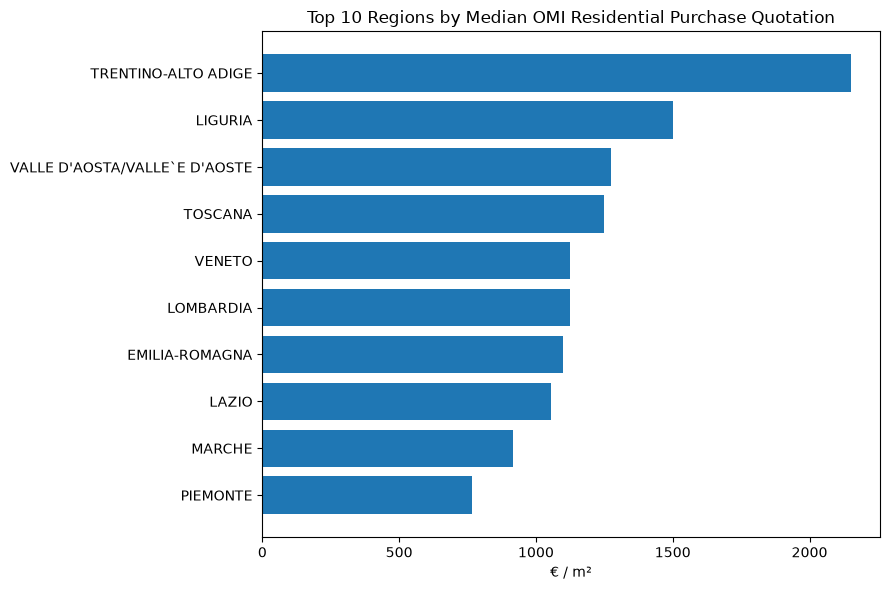

In [11]:
top_regions_latest = (
    regional_trend[regional_trend['reference_date'].eq(latest_date)]
    .nlargest(10, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(top_regions_latest['Regione'], top_regions_latest['median_compr_mid'])

ax.set_title('Top 10 Regions by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()


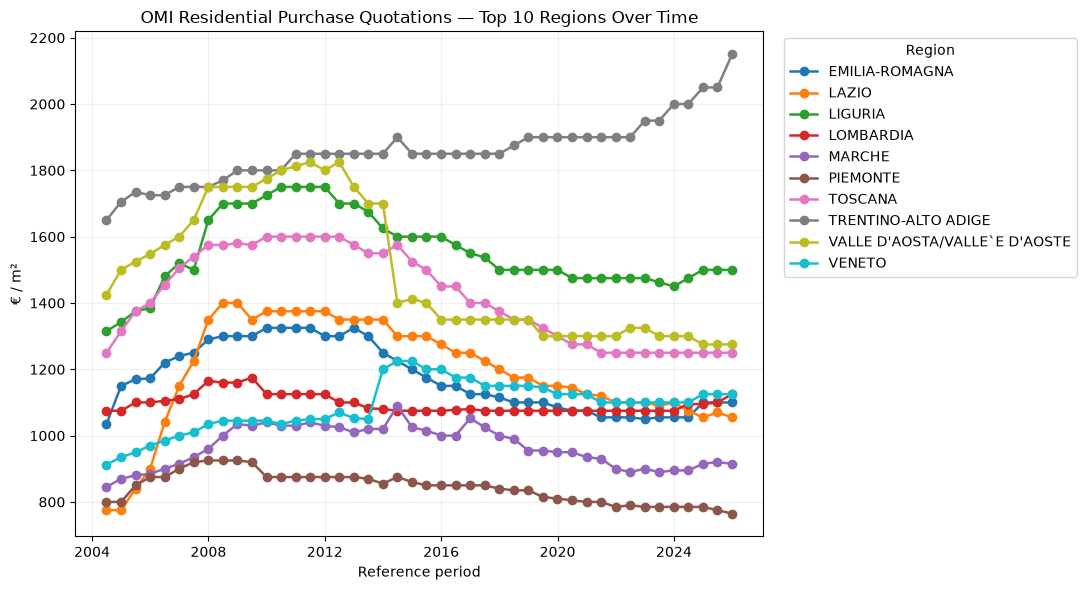

In [12]:
top_region_names = top_regions_latest['Regione']

plot_data = regional_trend[regional_trend['Regione'].isin(top_region_names)]

fig, ax = plt.subplots(figsize=(11, 6))

for regione, data in plot_data.groupby('Regione'):
    ax.plot(data['reference_date'], data['median_compr_mid'], marker='o', linewidth=1.8, label=regione)

ax.set_title('OMI Residential Purchase Quotations — Top 10 Regions Over Time')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


#### 6.2.2 Bottom 10 Regions

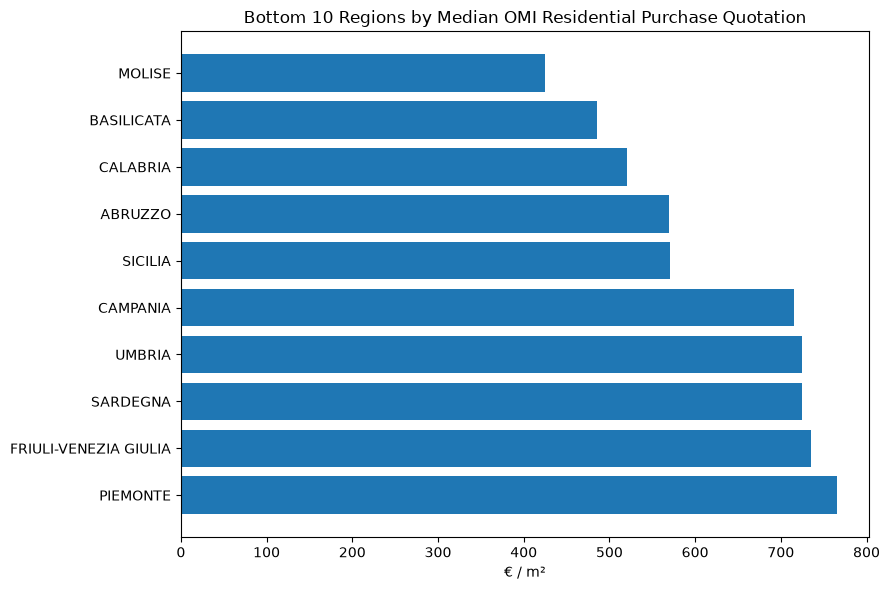

In [13]:
bottom_regions_latest = (
    regional_trend[regional_trend['reference_date'].eq(latest_date)]
    .nsmallest(10, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(bottom_regions_latest['Regione'], bottom_regions_latest['median_compr_mid'])

ax.set_title('Bottom 10 Regions by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()


> **Interpretation.** The gap between the top and bottom regional bar charts is a
> direct measure of geographical price dispersion in the Italian residential market. A
> wide gap (often several multiples) signals that "the national market" is really a
> collection of very different sub-markets, and that any national-level average should
> be read with caution when making local decisions.


### 6.3 Provincial Analysis

In [14]:
provincial_trend = (
    residential
    .groupby(['reference_date', 'Prov'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = provincial_trend['reference_date'].max()

display(provincial_trend.tail(10))


,reference_date,Prov,median_compr_mid,mean_compr_mid,observations
4478,2025-12-31,TV,1150.00,1207.291221,467
4479,2025-12-31,UD,775.00,820.537736,530
4480,2025-12-31,VA,1200.00,1262.097458,472
4481,2025-12-31,VB,925.00,999.872774,393
4482,2025-12-31,VC,645.00,748.481675,191
4483,2025-12-31,VE,1250.00,1558.449304,503
4484,2025-12-31,VI,1150.00,1142.216809,821
4485,2025-12-31,VR,1177.50,1434.568750,400
4486,2025-12-31,VT,925.00,971.548117,239
4487,2025-12-31,VV,411.25,489.698795,166


#### 6.3.1 Top 20 Provinces

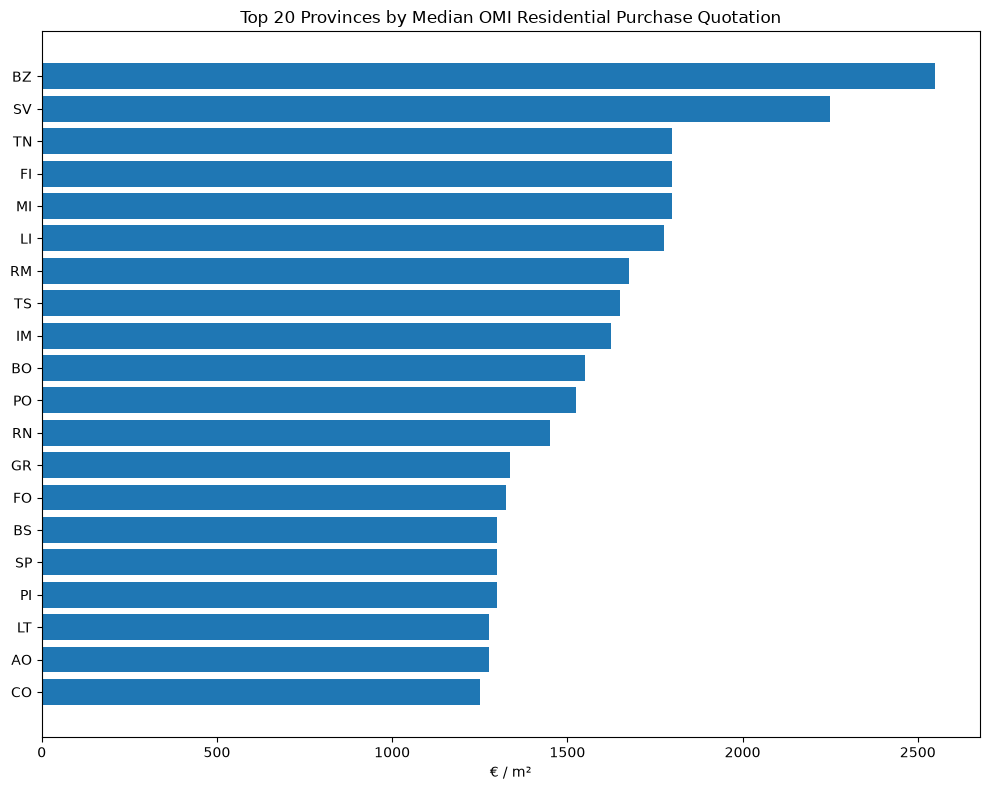

In [15]:
top_provinces_latest = (
    provincial_trend[provincial_trend['reference_date'].eq(latest_date)]
    .nlargest(20, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(top_provinces_latest['Prov'], top_provinces_latest['median_compr_mid'])

ax.set_title('Top 20 Provinces by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()


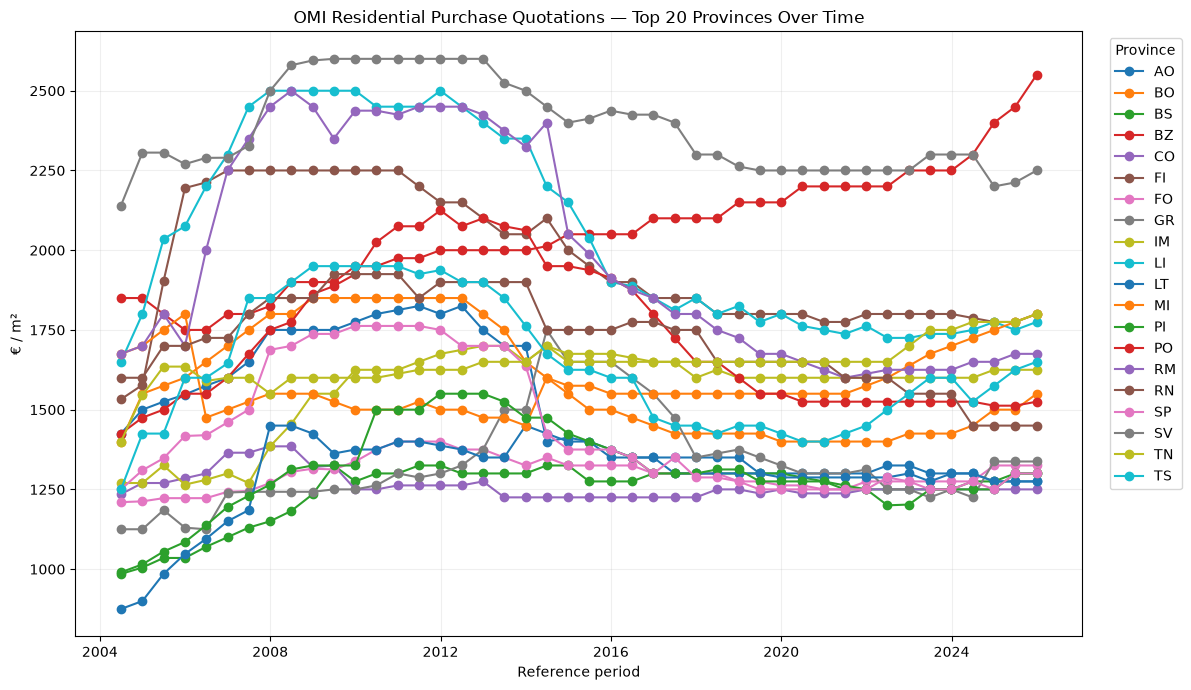

In [16]:
top_province_names = top_provinces_latest['Prov']

plot_data = provincial_trend[provincial_trend['Prov'].isin(top_province_names)]

fig, ax = plt.subplots(figsize=(12, 7))

for provincia, data in plot_data.groupby('Prov'):
    ax.plot(data['reference_date'], data['median_compr_mid'], marker='o', linewidth=1.5, label=provincia)

ax.set_title('OMI Residential Purchase Quotations — Top 20 Provinces Over Time')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Province', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


#### 6.3.2 Bottom 20 Provinces

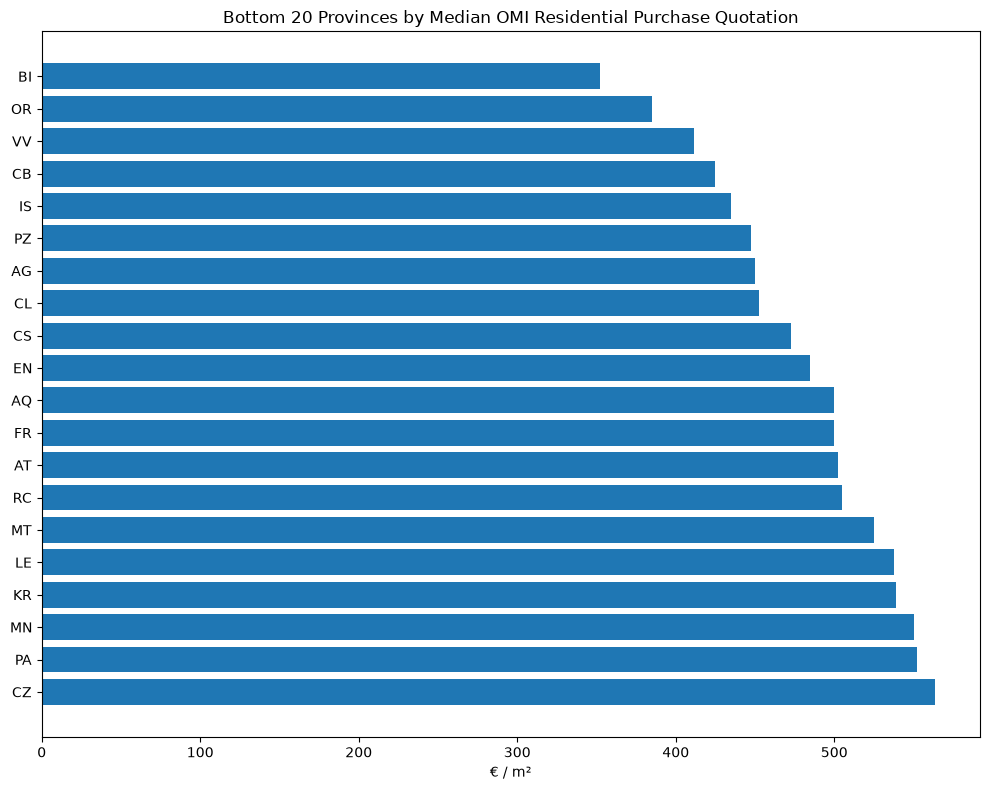

In [17]:
bottom_provinces_latest = (
    provincial_trend[provincial_trend['reference_date'].eq(latest_date)]
    .nsmallest(20, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(bottom_provinces_latest['Prov'], bottom_provinces_latest['median_compr_mid'])

ax.set_title('Bottom 20 Provinces by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()


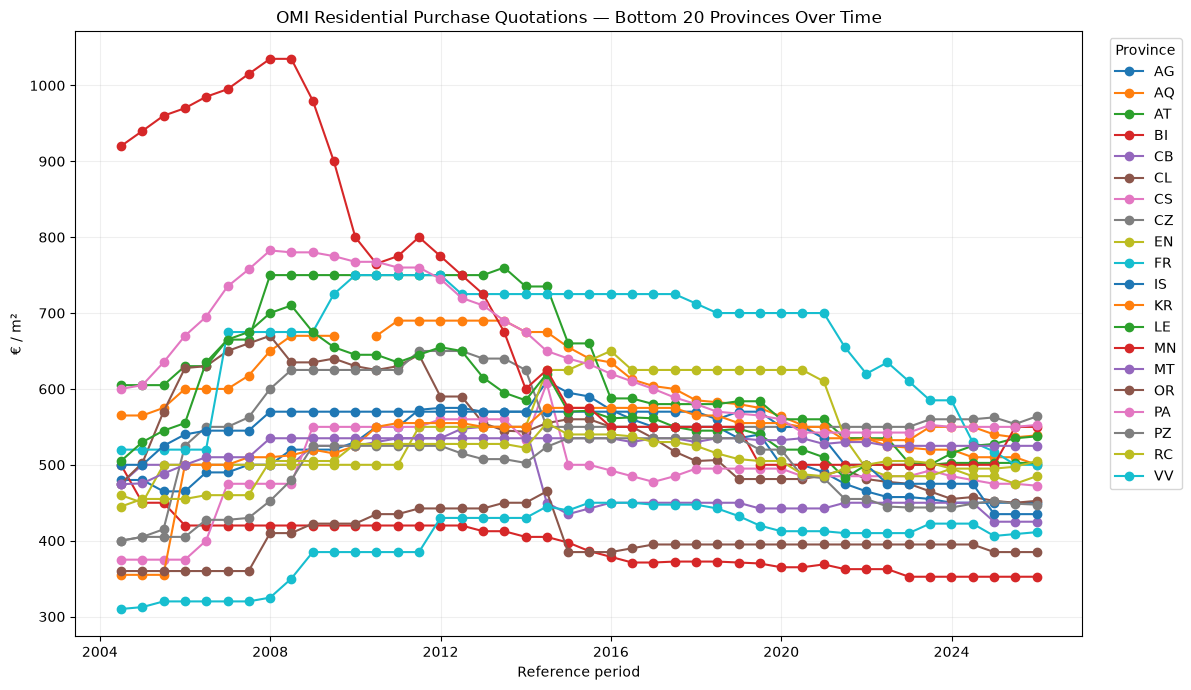

In [18]:
bottom_province_names = bottom_provinces_latest['Prov']

plot_data = provincial_trend[provincial_trend['Prov'].isin(bottom_province_names)]

fig, ax = plt.subplots(figsize=(12, 7))

for provincia, data in plot_data.groupby('Prov'):
    ax.plot(data['reference_date'], data['median_compr_mid'], marker='o', linewidth=1.5, label=provincia)

ax.set_title('OMI Residential Purchase Quotations — Bottom 20 Provinces Over Time')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Province', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


### 6.4 Municipal Analysis

In [19]:
municipal_trend = (
    residential
    .groupby(['reference_date', 'Comune_descrizione'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = municipal_trend['reference_date'].max()

display(municipal_trend.tail(10))


,reference_date,Comune_descrizione,median_compr_mid,mean_compr_mid,observations
352366,2025-12-31,ZOPPOLA,700.00,696.875,8
352367,2025-12-31,ZOVENCEDO,937.50,860.000,4
352368,2025-12-31,ZUBIENA,336.25,358.125,4
352369,2025-12-31,ZUCCARELLO,1425.00,1425.000,1
352370,2025-12-31,ZUGLIANO,1087.50,1096.250,8
352371,2025-12-31,ZUGLIO,545.00,565.000,3
352372,2025-12-31,ZUMAGLIA,347.50,347.500,2
352373,2025-12-31,ZUMPANO,610.00,612.000,5
352374,2025-12-31,ZUNGOLI,451.25,461.250,8
352375,2025-12-31,ZUNGRI,351.25,351.250,2


#### 6.4.1 Top 20 Municipalities

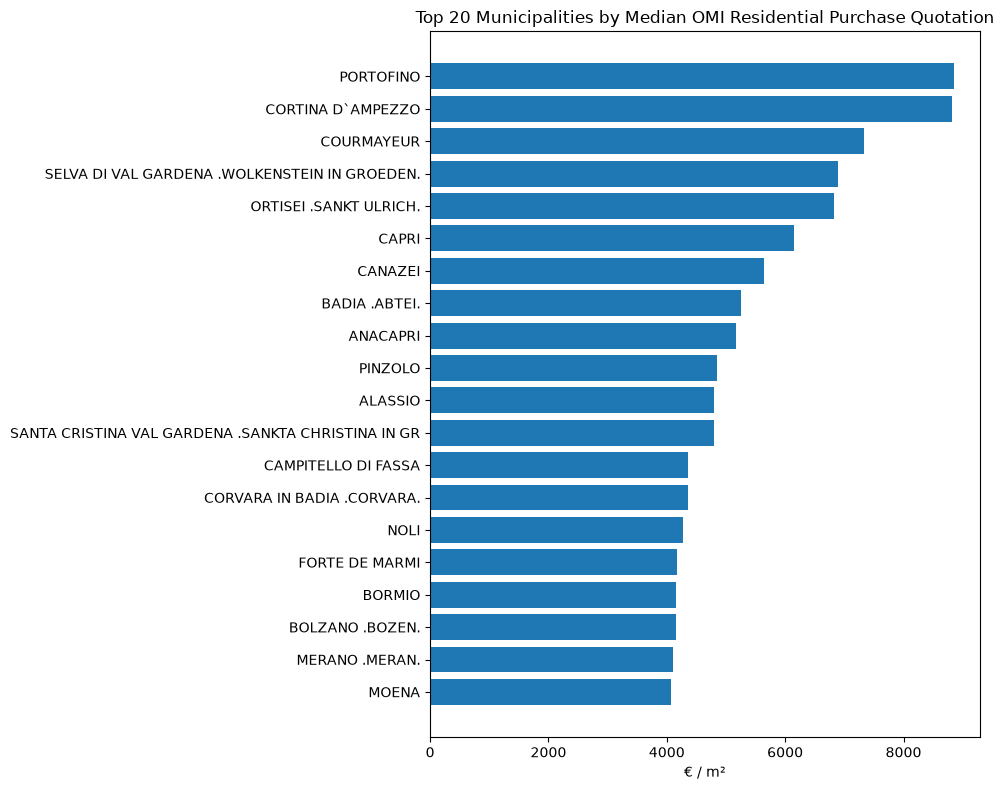

In [20]:
top_municipalities_latest = (
    municipal_trend[municipal_trend['reference_date'].eq(latest_date)]
    .nlargest(20, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(top_municipalities_latest['Comune_descrizione'], top_municipalities_latest['median_compr_mid'])

ax.set_title('Top 20 Municipalities by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()


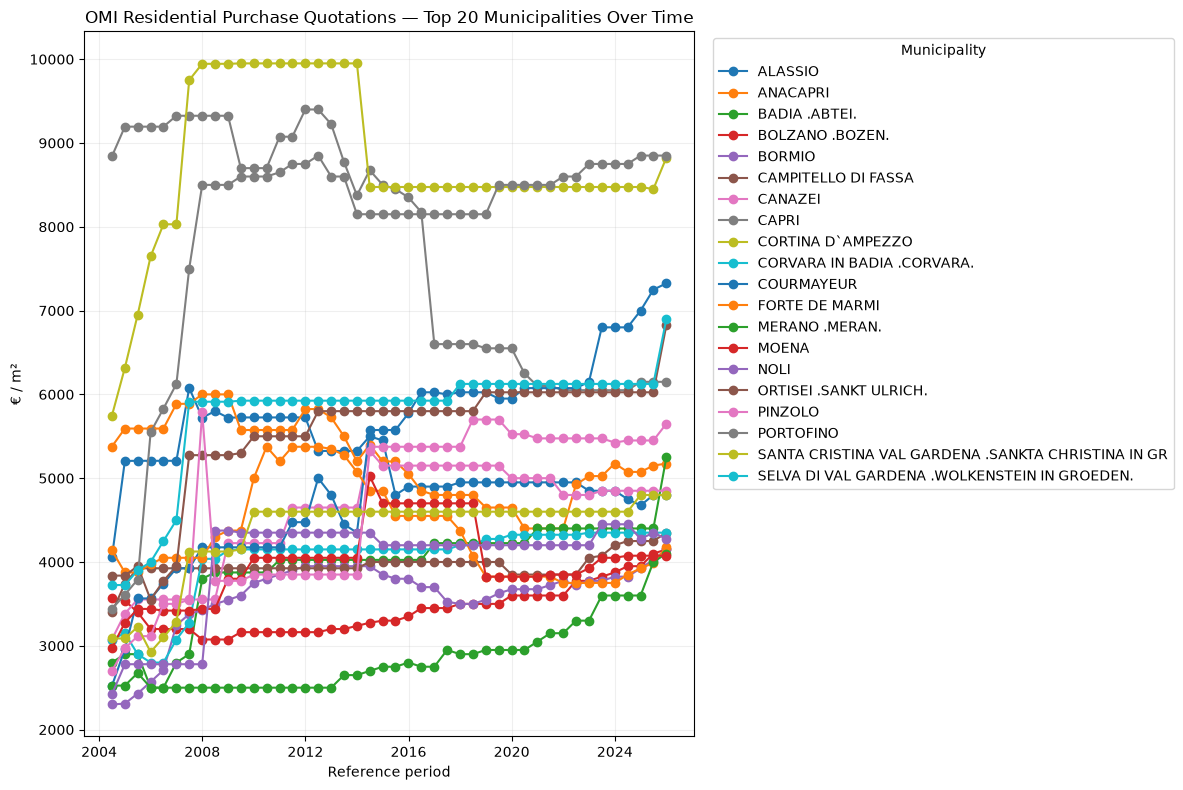

In [21]:
top_municipality_names = top_municipalities_latest['Comune_descrizione']

plot_data = municipal_trend[municipal_trend['Comune_descrizione'].isin(top_municipality_names)]

fig, ax = plt.subplots(figsize=(12, 8))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(data['reference_date'], data['median_compr_mid'], marker='o', linewidth=1.5, label=comune)

ax.set_title('OMI Residential Purchase Quotations — Top 20 Municipalities Over Time')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


#### 6.4.2 Bottom 20 Municipalities

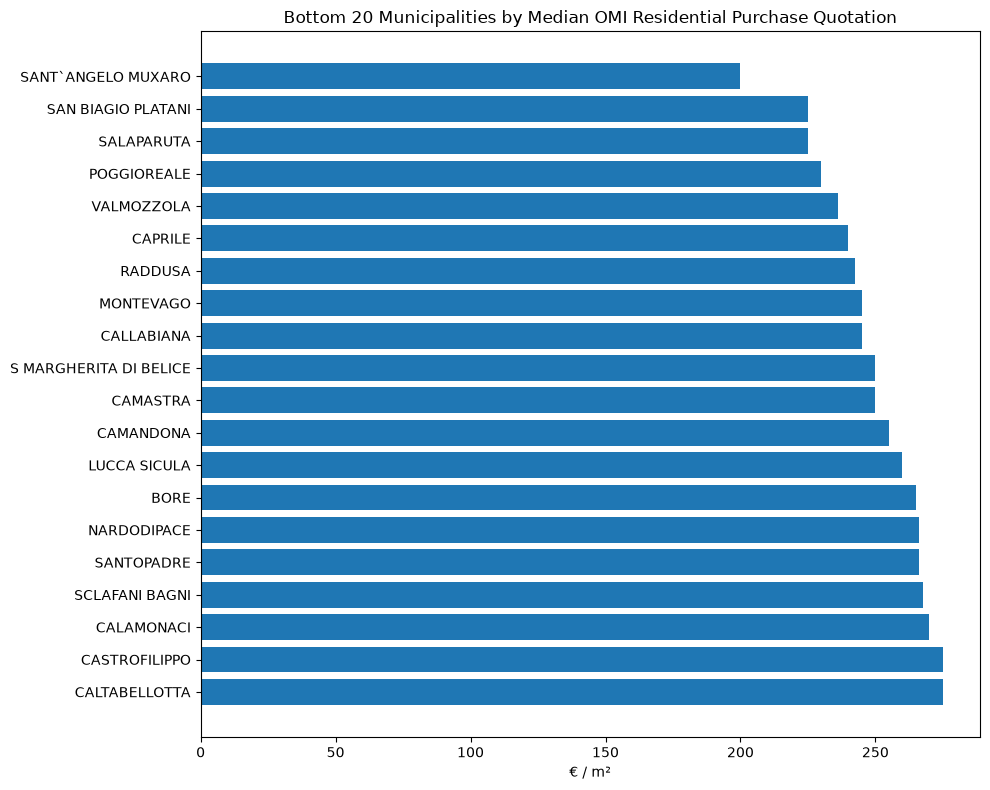

In [22]:
bottom_municipalities_latest = (
    municipal_trend[municipal_trend['reference_date'].eq(latest_date)]
    .nsmallest(20, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(bottom_municipalities_latest['Comune_descrizione'], bottom_municipalities_latest['median_compr_mid'])

ax.set_title('Bottom 20 Municipalities by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()


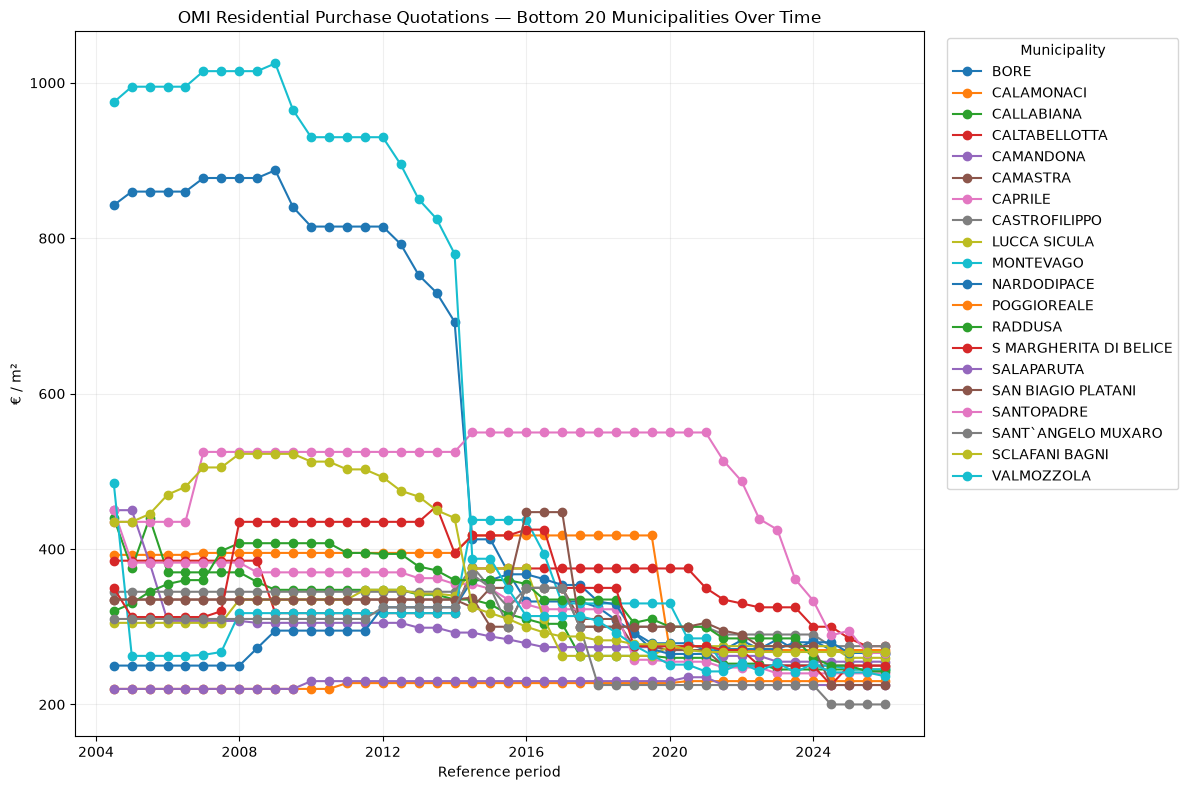

In [23]:
bottom_municipality_names = bottom_municipalities_latest['Comune_descrizione']

plot_data = municipal_trend[municipal_trend['Comune_descrizione'].isin(bottom_municipality_names)]

fig, ax = plt.subplots(figsize=(12, 8))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(data['reference_date'], data['median_compr_mid'], marker='o', linewidth=1.5, label=comune)

ax.set_title('OMI Residential Purchase Quotations — Bottom 20 Municipalities Over Time')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


> **Interpretation.** At municipal level, the top tier is typically dominated by a
> handful of large metropolitan areas and well-known tourist/lake destinations, while
> the bottom tier consists of small inland municipalities with low demand pressure. The
> time series above show whether each group's premium (or discount) versus the national
> median has been widening or narrowing over the observed period.


### 6.5 Zone Analysis (Municipality × OMI Zone)

In [24]:
municipal_zone_trend = (
    residential
    .groupby(['reference_date', 'Comune_descrizione', 'Zona'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = municipal_zone_trend['reference_date'].max()

display(municipal_zone_trend.tail(10))


,reference_date,Comune_descrizione,Zona,median_compr_mid,mean_compr_mid,observations
1066871,2025-12-31,ZUGLIO,B1,575.00,575.00,2
1066872,2025-12-31,ZUGLIO,R1,545.00,545.00,1
1066873,2025-12-31,ZUMAGLIA,B1,347.50,347.50,2
1066874,2025-12-31,ZUMPANO,B1,526.25,526.25,2
1066875,2025-12-31,ZUMPANO,E1,830.00,830.00,2
1066876,2025-12-31,ZUMPANO,R1,347.50,347.50,1
1066877,2025-12-31,ZUNGOLI,B1,526.25,527.50,4
1066878,2025-12-31,ZUNGOLI,R1,396.25,395.00,4
1066879,2025-12-31,ZUNGRI,B2,422.50,422.50,1
1066880,2025-12-31,ZUNGRI,R2,280.00,280.00,1


#### 6.5.1 Top 20 Municipal Zones

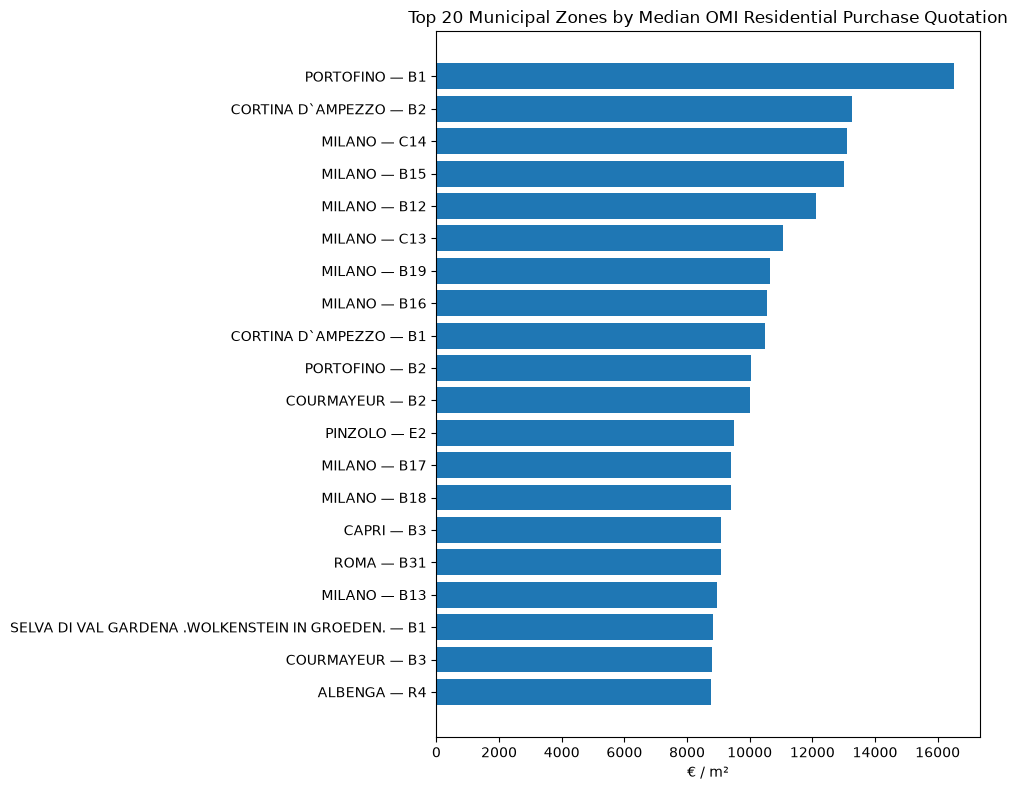

In [25]:
top_zones_latest = (
    municipal_zone_trend[municipal_zone_trend['reference_date'].eq(latest_date)]
    .nlargest(20, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_zones_latest['Comune_descrizione'] + ' — ' + top_zones_latest['Zona'],
    top_zones_latest['median_compr_mid']
)

ax.set_title('Top 20 Municipal Zones by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()


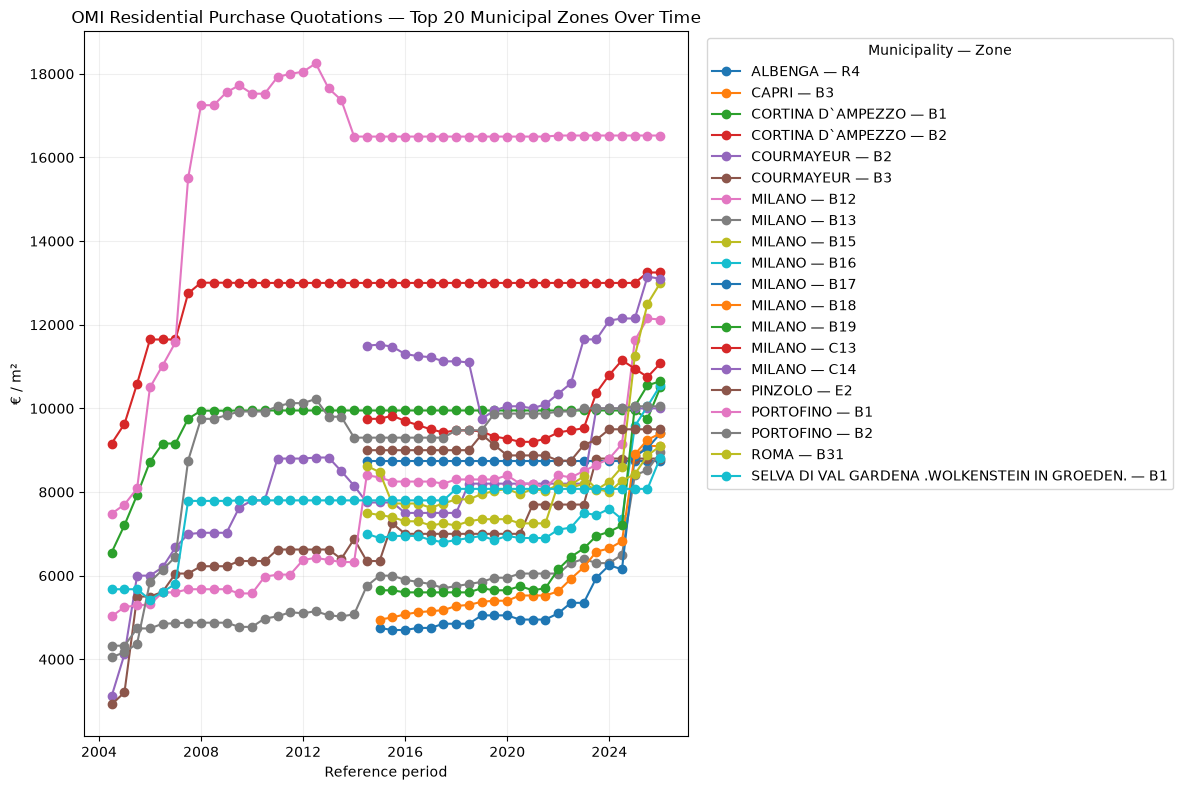

In [26]:
top_zone_keys = top_zones_latest[['Comune_descrizione', 'Zona']]

plot_data = municipal_zone_trend.merge(top_zone_keys, on=['Comune_descrizione', 'Zona'], how='inner')

fig, ax = plt.subplots(figsize=(12, 8))

for (comune, zona), data in plot_data.groupby(['Comune_descrizione', 'Zona']):
    ax.plot(data['reference_date'], data['median_compr_mid'], marker='o', linewidth=1.5, label=f'{comune} — {zona}')

ax.set_title('OMI Residential Purchase Quotations — Top 20 Municipal Zones Over Time')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality — Zone', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


#### 6.5.2 Bottom 20 Municipal Zones

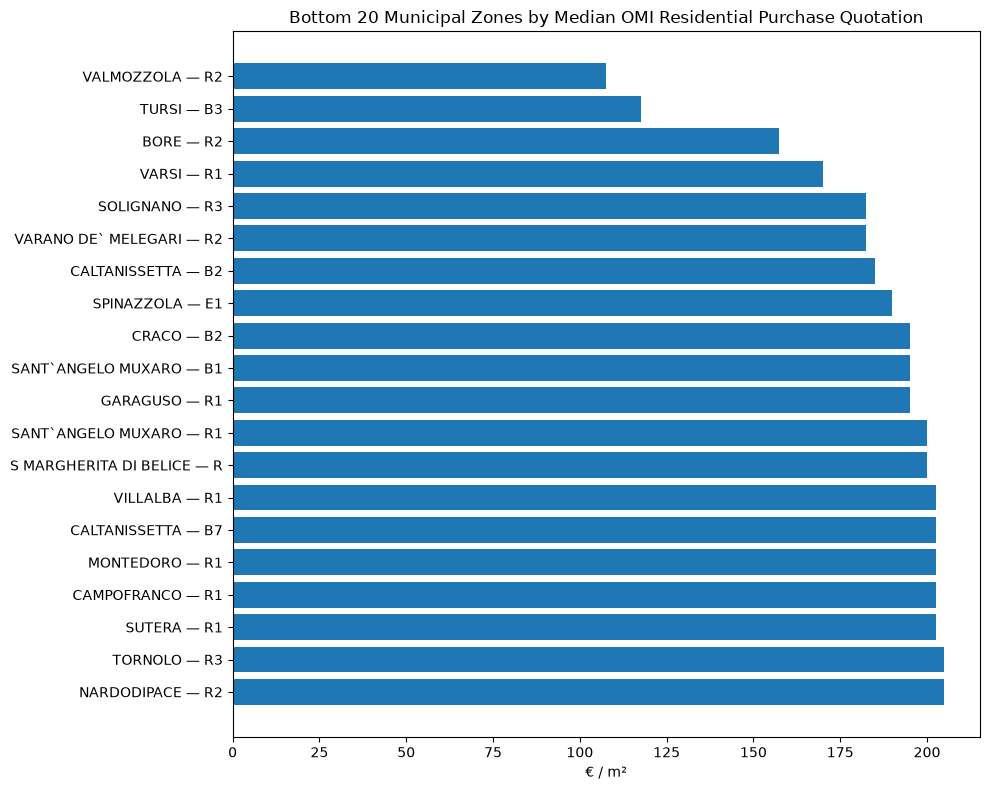

In [27]:
bottom_zones_latest = (
    municipal_zone_trend[municipal_zone_trend['reference_date'].eq(latest_date)]
    .nsmallest(20, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    bottom_zones_latest['Comune_descrizione'] + ' — ' + bottom_zones_latest['Zona'],
    bottom_zones_latest['median_compr_mid']
)

ax.set_title('Bottom 20 Municipal Zones by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()


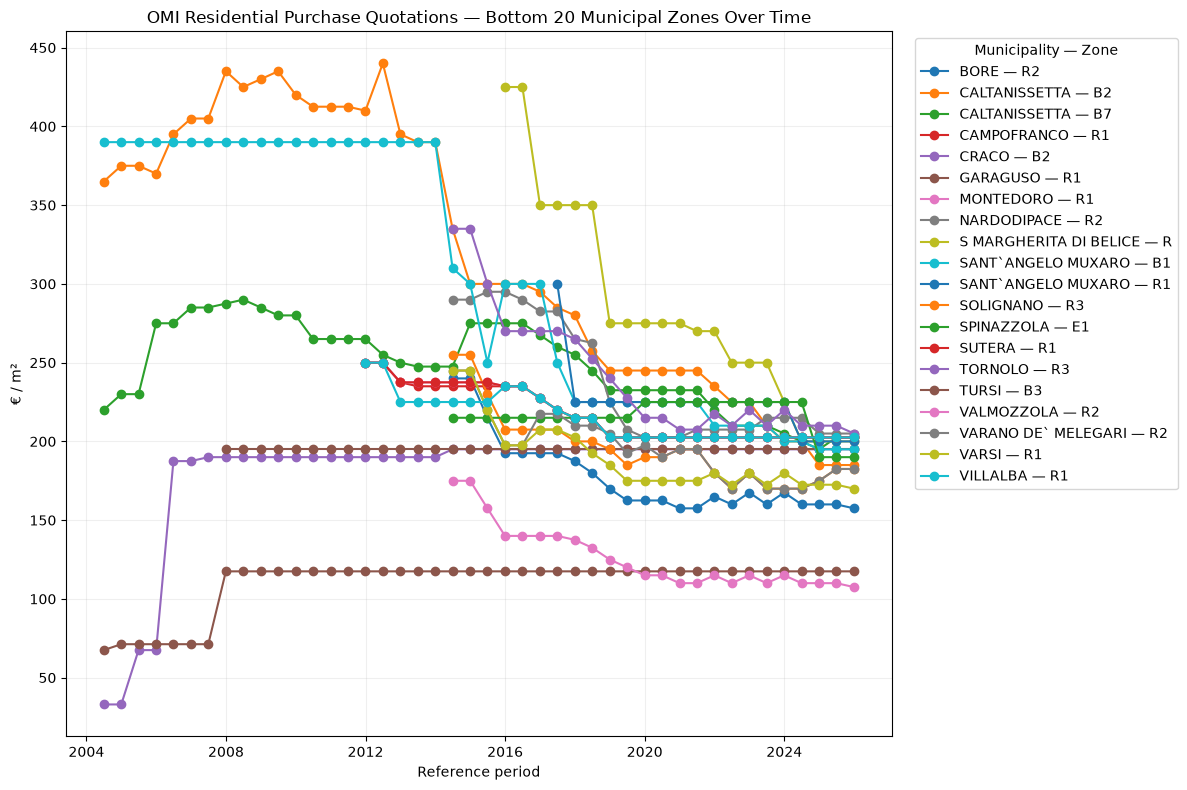

In [28]:
bottom_zone_keys = bottom_zones_latest[['Comune_descrizione', 'Zona']]

plot_data = municipal_zone_trend.merge(bottom_zone_keys, on=['Comune_descrizione', 'Zona'], how='inner')

fig, ax = plt.subplots(figsize=(12, 8))

for (comune, zona), data in plot_data.groupby(['Comune_descrizione', 'Zona']):
    ax.plot(data['reference_date'], data['median_compr_mid'], marker='o', linewidth=1.5, label=f'{comune} — {zona}')

ax.set_title('OMI Residential Purchase Quotations — Bottom 20 Municipal Zones Over Time')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality — Zone', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


> **Interpretation.** The zone level is the finest granularity in the OMI data and is
> where within-city heterogeneity becomes visible: prime city-centre zones versus
> peripheral zones of the *same* municipality can differ by a large multiple, which a
> municipality-level average would completely mask (this is examined quantitatively in
> Section 8.6).


## 7. Regional Focus: Lombardy & Brescia

This section drills into a specific region (Lombardy) and, within it, a specific
province (Brescia), to illustrate how the same trend-analysis approach applies at
increasingly local levels. Replace `'LOMBARDIA'` / `'BS'` below to reuse this section for
any other region or province.


### 7.1 Lombardy — Provinces

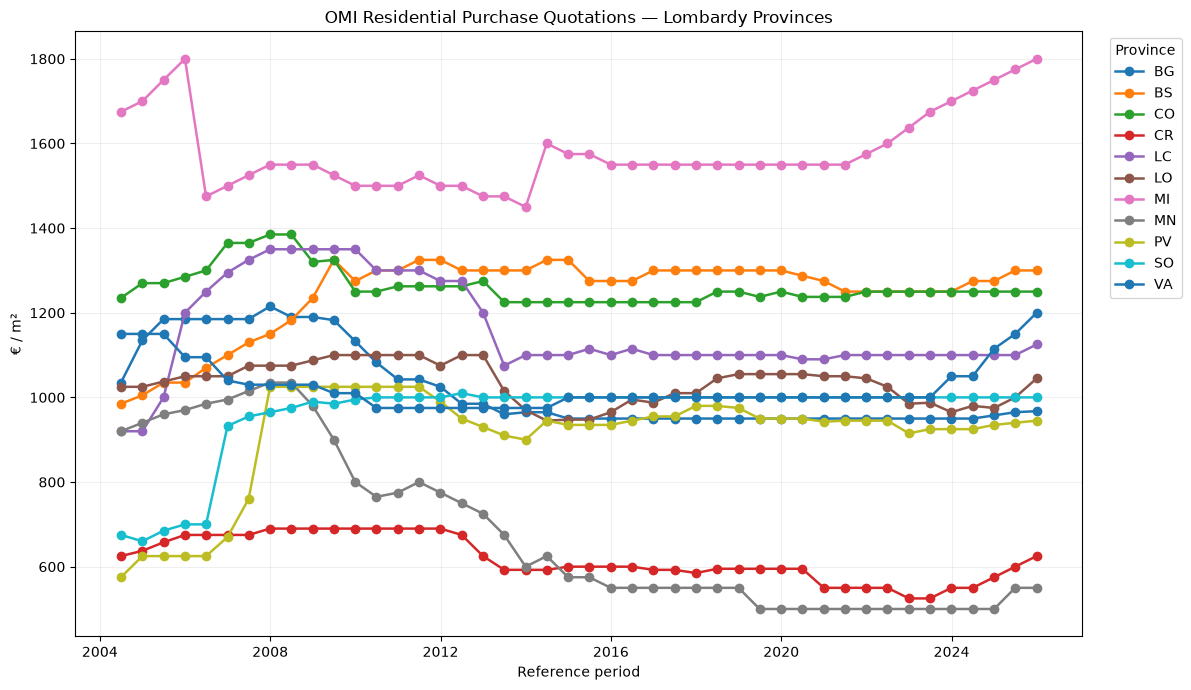

In [29]:
lombardia_trend = (
    residential[residential['Regione'].eq('LOMBARDIA')]
    .groupby(['reference_date', 'Prov'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

fig, ax = plt.subplots(figsize=(12, 7))

for provincia, data in lombardia_trend.groupby('Prov'):
    ax.plot(data['reference_date'], data['median_compr_mid'], marker='o', linewidth=1.8, label=provincia)

ax.set_title('OMI Residential Purchase Quotations — Lombardy Provinces')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Province', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


### 7.2 Brescia — Municipalities

To keep a large number of municipalities readable, the province's municipalities are
split into three tiers by their most recent median quotation: top 10 (most expensive),
a middle 10 sampled around the median, and bottom 10 (least expensive).


In [30]:
brescia_trend = (
    residential[residential['Prov'].eq('BS')]
    .groupby(['reference_date', 'Comune_descrizione'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = brescia_trend['reference_date'].max()

latest_brescia = (
    brescia_trend[brescia_trend['reference_date'].eq(latest_date)]
    .sort_values('median_compr_mid', ascending=False)
)

top_10_municipalities = latest_brescia.head(10)['Comune_descrizione']

middle_10_municipalities = (
    latest_brescia
    .iloc[len(latest_brescia) // 2 - 5 : len(latest_brescia) // 2 + 5]
    ['Comune_descrizione']
)

bottom_10_municipalities = latest_brescia.tail(10)['Comune_descrizione']


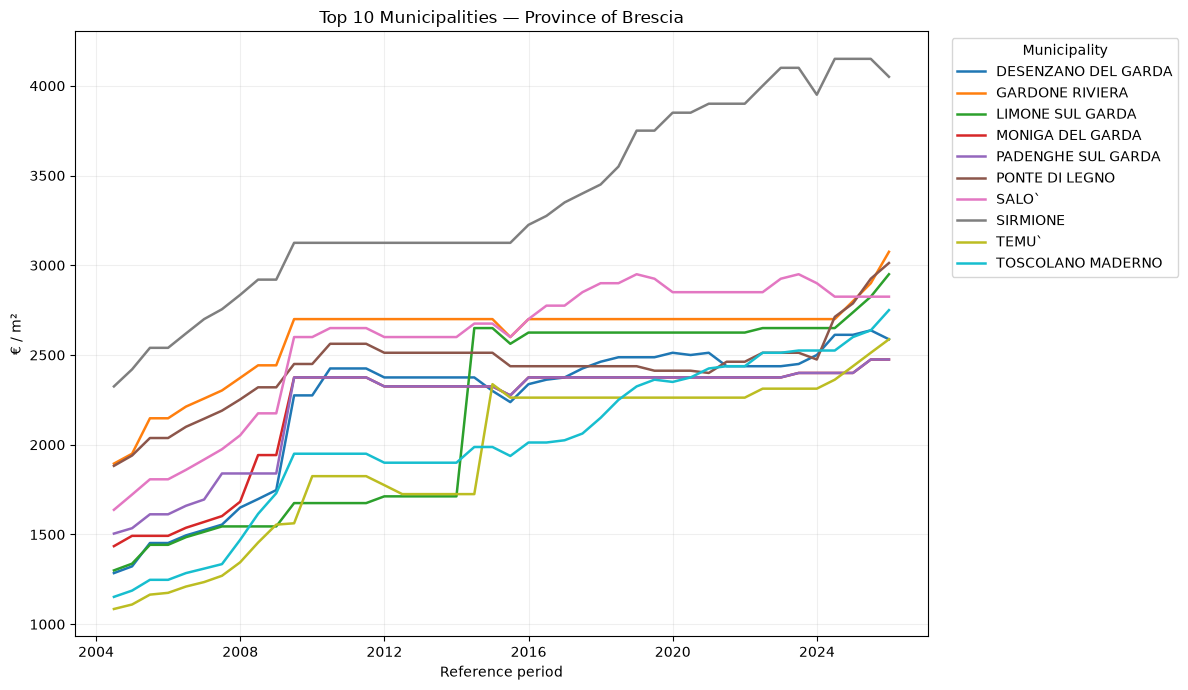

In [31]:
plot_data = brescia_trend[brescia_trend['Comune_descrizione'].isin(top_10_municipalities)]

fig, ax = plt.subplots(figsize=(12, 7))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(data['reference_date'], data['median_compr_mid'], linewidth=1.8, label=comune)

ax.set_title('Top 10 Municipalities — Province of Brescia')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


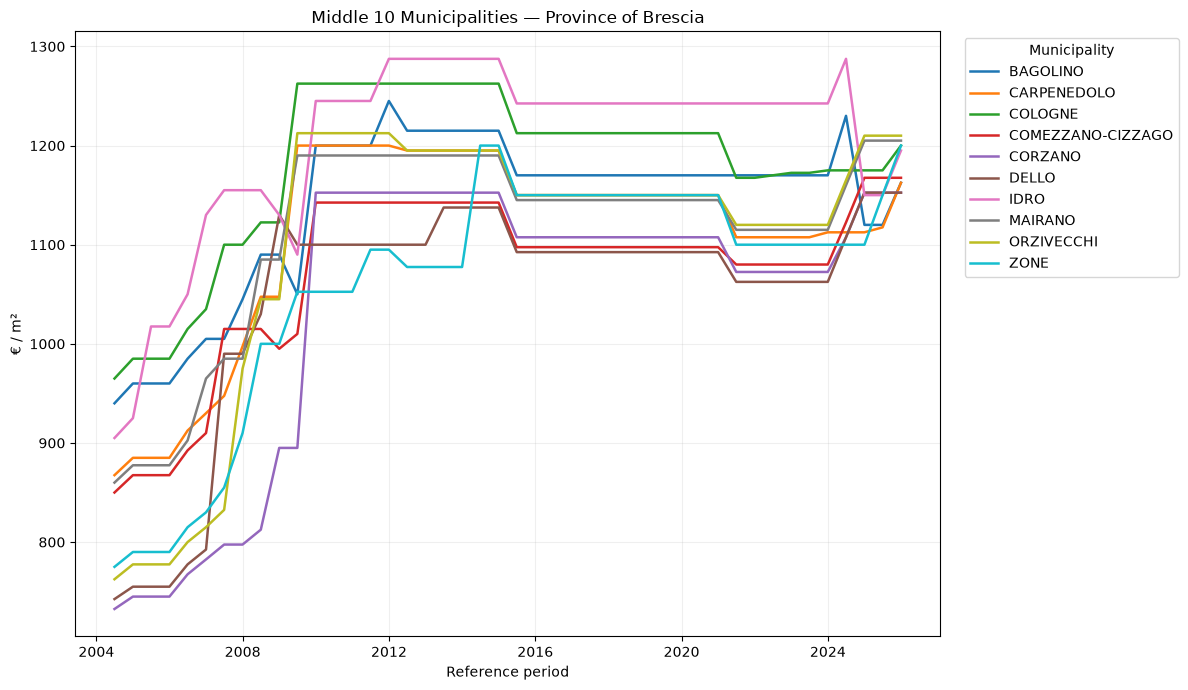

In [32]:
plot_data = brescia_trend[brescia_trend['Comune_descrizione'].isin(middle_10_municipalities)]

fig, ax = plt.subplots(figsize=(12, 7))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(data['reference_date'], data['median_compr_mid'], linewidth=1.8, label=comune)

ax.set_title('Middle 10 Municipalities — Province of Brescia')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


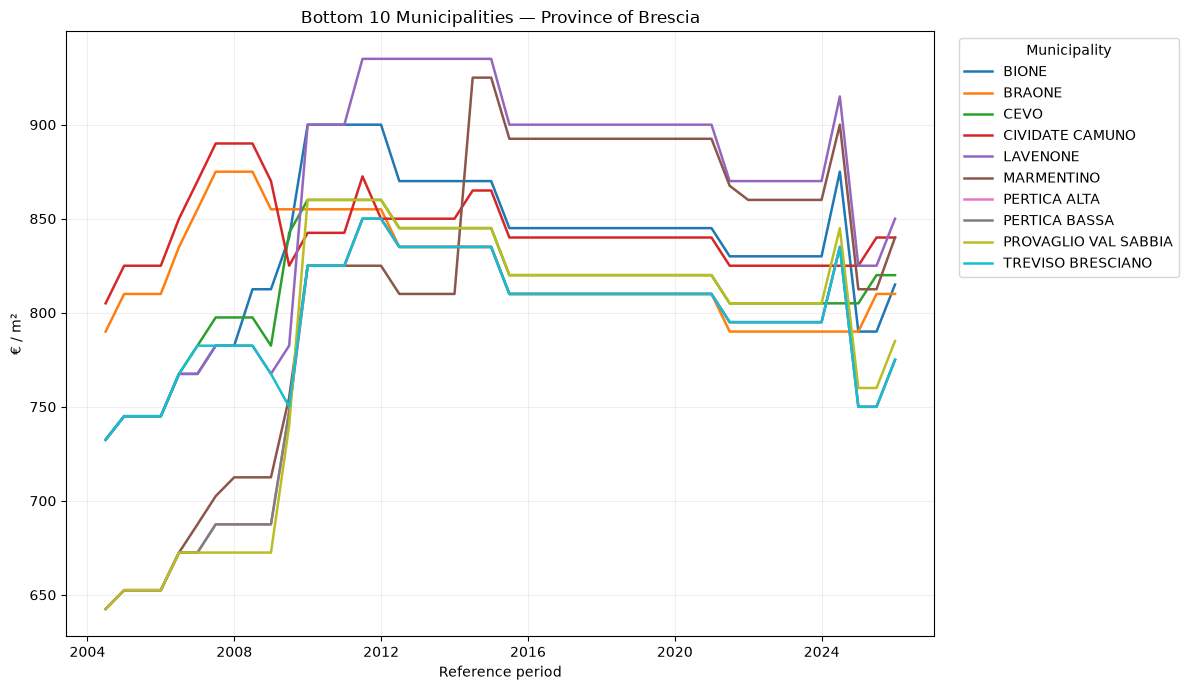

In [33]:
plot_data = brescia_trend[brescia_trend['Comune_descrizione'].isin(bottom_10_municipalities)]

fig, ax = plt.subplots(figsize=(12, 7))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(data['reference_date'], data['median_compr_mid'], linewidth=1.8, label=comune)

ax.set_title('Bottom 10 Municipalities — Province of Brescia')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


#### 7.2.1 Brescia — Year-by-Year Price Matrix and Ranking

In [34]:
brescia_yearly = (
    residential[residential['Prov'].eq('BS')]
    .assign(year=lambda x: x['reference_date'].dt.year)
    .groupby(['Comune_descrizione', 'year'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

# Municipality x year price matrix
price_matrix = brescia_yearly.pivot(index='Comune_descrizione', columns='year', values='median_compr_mid')

# Ranking in the latest available year
latest_year = price_matrix.columns.max()

ranking_latest_year = (
    price_matrix[latest_year]
    .rank(method='min', ascending=False)
    .astype('Int64')
    .rename('rank_latest')
)

# Percentage change between the first and the latest available year
first_year = price_matrix.columns.min()

change_pct = (
    (price_matrix[latest_year] / price_matrix[first_year] - 1) * 100
).rename('change_pct')

# Final table
brescia_price_matrix = (
    price_matrix
    .join(ranking_latest_year)
    .join(change_pct)
    .sort_values('rank_latest')
)

brescia_price_matrix


,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2018,2019,2020,2021,2022,2023,2024,2025,rank_latest,change_pct
Comune_descrizione,,,,,,,,,,,,,,,,,,,,,
SIRMIONE,2372.5,2540.0,2660.0,2795.0,2920.0,3125.0,3125.0,3125.0,3125.0,3125.0,...,3650.0,3800.0,3875.0,3900.0,4050.0,4025.0,4150.0,4100.0,1,72.813488
PONTE DI LEGNO,1910.0,2037.5,2122.5,2252.5,2320.0,2450.0,2562.5,2537.5,2512.5,2512.5,...,2437.5,2412.5,2400.0,2462.5,2512.5,2475.0,2750.0,2962.5,2,55.104712
GARDONE RIVIERA,1922.5,2147.5,2235.0,2337.5,2442.5,2700.0,2700.0,2700.0,2700.0,2700.0,...,2700.0,2700.0,2700.0,2700.0,2700.0,2700.0,2750.0,2950.0,3,53.446034
LIMONE SUL GARDA,1317.5,1442.5,1497.5,1545.0,1545.0,1675.0,1675.0,1687.5,1712.5,1712.5,...,2625.0,2625.0,2625.0,2625.0,2650.0,2650.0,2700.0,2875.0,4,118.216319
SALO`,1677.5,1807.5,1887.5,2012.5,2175.0,2600.0,2650.0,2650.0,2600.0,2600.0,...,2925.0,2887.5,2850.0,2850.0,2850.0,2925.0,2825.0,2825.0,5,68.405365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PERTICA BASSA,647.5,652.5,672.5,687.5,687.5,815.0,825.0,850.0,835.0,835.0,...,810.0,810.0,810.0,795.0,795.0,795.0,792.5,762.5,201,17.760618
LONATO,1022.5,1080.0,1132.5,1192.5,1320.0,1425.0,1450.0,1437.5,1425.0,1450.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
MAGASA,647.5,652.5,680.0,715.0,725.0,815.0,815.0,815.0,815.0,850.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN


In [35]:
observations_matrix = brescia_yearly.pivot(index='Comune_descrizione', columns='year', values='observations')

display(observations_matrix.style.format('{:,.0f}'))


year,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Comune_descrizione,,,,,,,,,,,,,,,,,,,,,,
ACQUAFREDDA,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ADRO,10,10,9,8,8,11,14,14,14,14,8,8,8,8,8,8,8,8,8,8,8,8
AGNOSINE,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ALFIANELLO,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ANFO,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ANGOLO TERME,4,4,4,4,4,6,8,8,8,8,6,6,6,6,6,6,6,6,6,6,6,6
ARTOGNE,6,6,6,6,6,9,12,12,12,12,9,8,8,8,8,8,8,8,8,8,8,8
AZZANO MELLA,4,4,3,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
BAGNOLO MELLA,6,6,6,6,9,12,12,12,12,12,8,8,8,8,8,8,8,8,8,8,8,8


In [36]:
brescia_summary = pd.DataFrame({
    'latest_price': price_matrix[latest_year],
    'rank_latest': ranking_latest_year,
    'first_price': price_matrix[first_year],
    'change_pct': change_pct,
    'observations_latest': observations_matrix[latest_year]
}).sort_values('rank_latest')

display(
    brescia_summary.style.format({
        'latest_price': '€ {:,.0f}',
        'first_price': '€ {:,.0f}',
        'rank_latest': '{:.0f}',
        'change_pct': '{:+.1f}%',
        'observations_latest': '{:,.0f}'
    })
)


,latest_price,rank_latest,first_price,change_pct,observations_latest
Comune_descrizione,,,,,
SIRMIONE,"€ 4,100",1,"€ 2,372",+72.8%,18
PONTE DI LEGNO,"€ 2,962",2,"€ 1,910",+55.1%,24
GARDONE RIVIERA,"€ 2,950",3,"€ 1,922",+53.4%,22
LIMONE SUL GARDA,"€ 2,875",4,"€ 1,318",+118.2%,12
SALO`,"€ 2,825",5,"€ 1,678",+68.4%,18
TOSCOLANO MADERNO,"€ 2,688",6,"€ 1,170",+129.7%,12
DESENZANO DEL GARDA,"€ 2,588",7,"€ 1,302",+98.7%,28
TEMU`,"€ 2,550",8,"€ 1,090",+133.9%,12
PADENGHE SUL GARDA,"€ 2,475",9,"€ 1,520",+62.8%,18


> **Interpretation.** `rank_latest` orders Brescia's municipalities by current price
> level, while `change_pct` measures how much each municipality's price has moved since
> the first available year. Reading the two together separates *where prices are high
> today* from *where prices have grown the most* — the two rankings need not agree.


### 7.3 Brescia — Municipality × Zone

The same top/middle/bottom tiering is repeated at zone level within the province, to
show intra-provincial heterogeneity beyond municipal boundaries.


In [37]:
brescia_zone_trend = (
    residential[residential['Prov'].eq('BS')]
    .groupby(['reference_date', 'Comune_descrizione', 'Zona'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = brescia_zone_trend['reference_date'].max()

latest_brescia_zones = (
    brescia_zone_trend[brescia_zone_trend['reference_date'].eq(latest_date)]
    .sort_values('median_compr_mid', ascending=False)
)

top_10_muni_zones = latest_brescia_zones.head(10)[['Comune_descrizione', 'Zona']]

middle_10_muni_zones = (
    latest_brescia_zones
    .iloc[len(latest_brescia_zones) // 2 - 5 : len(latest_brescia_zones) // 2 + 5]
    [['Comune_descrizione', 'Zona']]
)

bottom_10_muni_zones = latest_brescia_zones.tail(10)[['Comune_descrizione', 'Zona']]


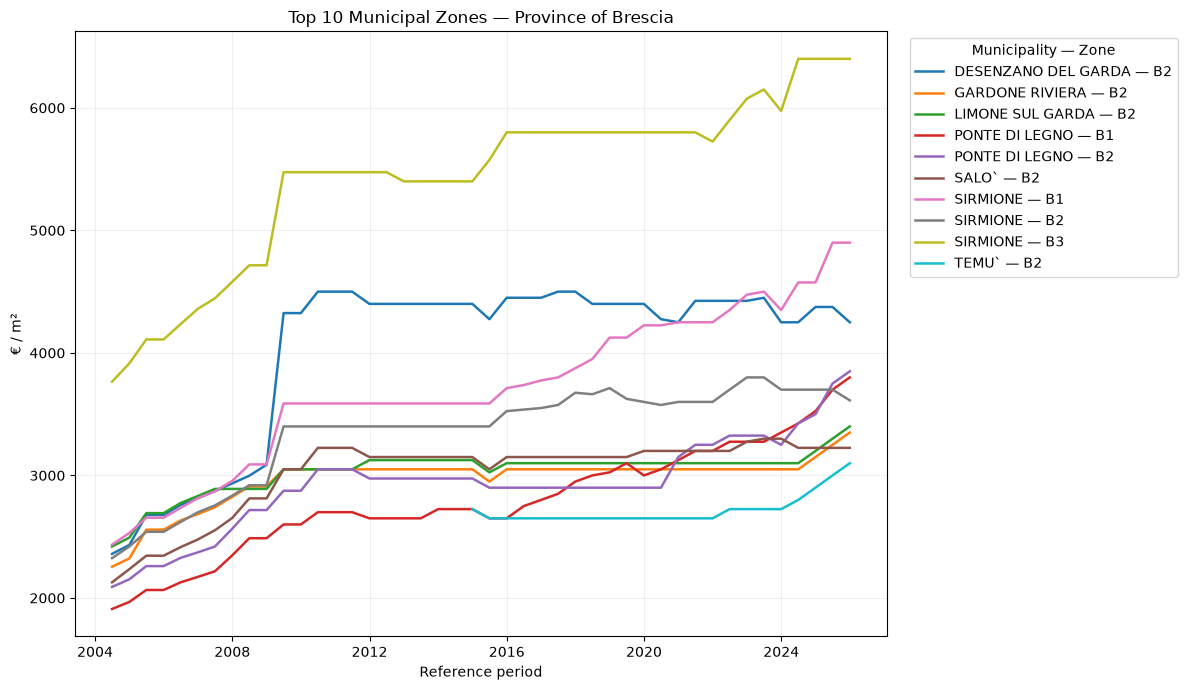

In [38]:
plot_data = brescia_zone_trend.merge(top_10_muni_zones, on=['Comune_descrizione', 'Zona'], how='inner')

fig, ax = plt.subplots(figsize=(12, 7))

for (comune, zona), data in plot_data.groupby(['Comune_descrizione', 'Zona']):
    ax.plot(data['reference_date'], data['median_compr_mid'], linewidth=1.8, label=f'{comune} — {zona}')

ax.set_title('Top 10 Municipal Zones — Province of Brescia')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality — Zone', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


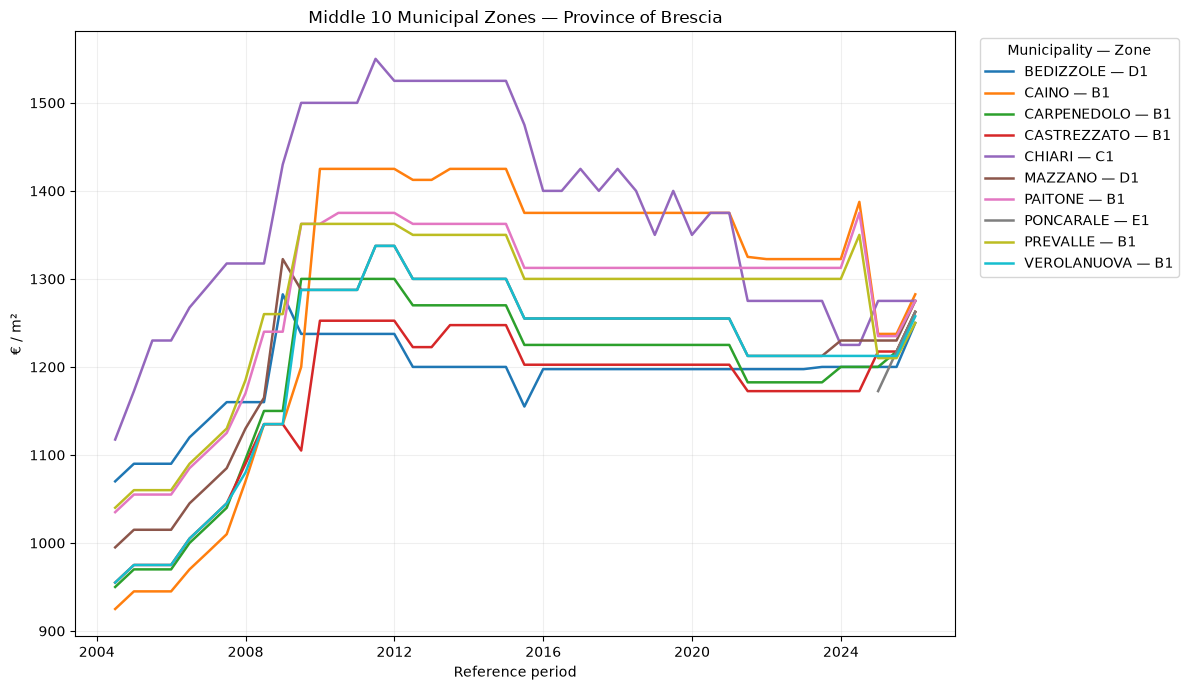

In [39]:
plot_data = brescia_zone_trend.merge(middle_10_muni_zones, on=['Comune_descrizione', 'Zona'], how='inner')

fig, ax = plt.subplots(figsize=(12, 7))

for (comune, zona), data in plot_data.groupby(['Comune_descrizione', 'Zona']):
    ax.plot(data['reference_date'], data['median_compr_mid'], linewidth=1.8, label=f'{comune} — {zona}')

ax.set_title('Middle 10 Municipal Zones — Province of Brescia')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality — Zone', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


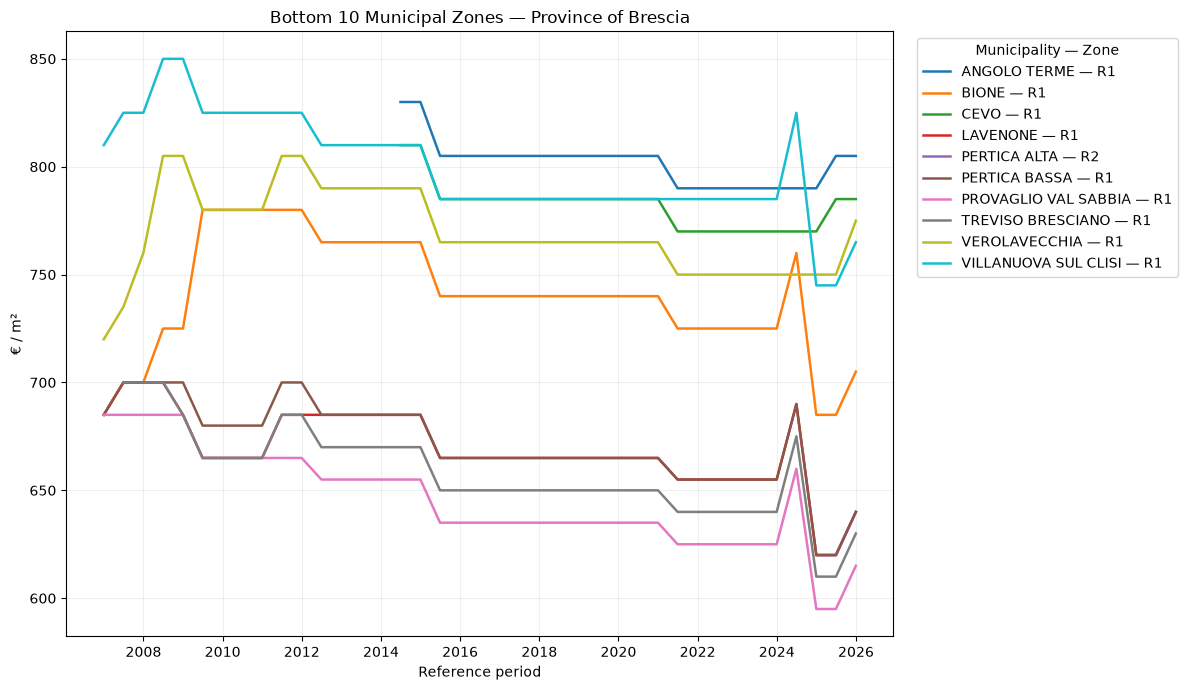

In [40]:
plot_data = brescia_zone_trend.merge(bottom_10_muni_zones, on=['Comune_descrizione', 'Zona'], how='inner')

fig, ax = plt.subplots(figsize=(12, 7))

for (comune, zona), data in plot_data.groupby(['Comune_descrizione', 'Zona']):
    ax.plot(data['reference_date'], data['median_compr_mid'], linewidth=1.8, label=f'{comune} — {zona}')

ax.set_title('Bottom 10 Municipal Zones — Province of Brescia')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend(title='Municipality — Zone', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
plt.show()


## 8. Growth & Risk Analytics

Price *levels* only tell half the story. This section turns to price *dynamics* at the
municipality-zone level: semester-over-semester and year-over-year growth, drawdowns
from historical peaks, compound annual growth rate (CAGR), growth volatility and growth
persistence. All metrics are computed once, in a single table, and reused throughout the
section to avoid duplicated aggregation logic.


### 8.1 Feature Engineering

For every `(Comune_descrizione, Zona)` pair, sorted chronologically, we derive:

- `period` — a human-readable semester label (`YYYY-S1` / `YYYY-S2`);
- `growth_pct` — semester-over-semester percentage change in the median quotation;
- `yoy_growth_pct` — year-over-year percentage change (two semesters apart, since OMI
  releases are semiannual);
- `rolling_max` / `drawdown_pct` — the running historical peak price and the current
  percentage gap below it, analogous to a financial drawdown.

**`MIN_PERIODS`.** Metrics that summarise a whole series — CAGR, growth volatility,
persistence — are only meaningful with enough observations behind them. A
municipality-zone with only two semesters of history can show a CAGR of +200% or -80%
purely from noise. We therefore define a minimum coverage threshold and apply it before
any such ranking; series below the threshold remain in the full table but are excluded
from "top/bottom" leaderboards.


In [41]:
MIN_PERIODS = 4  # minimum number of semesters (2 years) required for growth-rate rankings

national_zone_trend = (
    residential
    .groupby(['reference_date', 'Comune_descrizione', 'Zona'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
    .sort_values(['Comune_descrizione', 'Zona', 'reference_date'])
)

# Semester label
national_zone_trend['period'] = (
    national_zone_trend['reference_date'].dt.year.astype(str)
    + '-S'
    + national_zone_trend['reference_date'].dt.month.map({6: 1, 12: 2}).astype(str)
)

# Semester-over-semester growth
national_zone_trend['growth_pct'] = (
    national_zone_trend
    .groupby(['Comune_descrizione', 'Zona'])['median_compr_mid']
    .pct_change()
    .mul(100)
)

# Year-over-year growth (2 semesters apart). Note: this assumes no missing semesters
# within a series — a gap in coverage would make this compare non-adjacent years.
national_zone_trend['yoy_growth_pct'] = (
    national_zone_trend
    .groupby(['Comune_descrizione', 'Zona'])['median_compr_mid']
    .pct_change(2)
    .mul(100)
)

# Rolling historical maximum price
national_zone_trend['rolling_max'] = (
    national_zone_trend
    .groupby(['Comune_descrizione', 'Zona'])['median_compr_mid']
    .cummax()
)

# Drawdown from the running historical maximum
national_zone_trend['drawdown_pct'] = (
    (national_zone_trend['median_compr_mid'] / national_zone_trend['rolling_max']) - 1
) * 100

national_zone_trend.tail(10)


,reference_date,Comune_descrizione,Zona,median_compr_mid,mean_compr_mid,observations,period,growth_pct,yoy_growth_pct,rolling_max,drawdown_pct
859715,2021-06-30,ZUNGRI,R2,267.5,267.5,1,2021-S1,0.000000,0.000000,295.0,-9.322034
882805,2021-12-31,ZUNGRI,R2,267.5,267.5,1,2021-S2,0.000000,0.000000,295.0,-9.322034
905891,2022-06-30,ZUNGRI,R2,267.5,267.5,1,2022-S1,0.000000,0.000000,295.0,-9.322034
928980,2022-12-31,ZUNGRI,R2,267.5,267.5,1,2022-S2,0.000000,0.000000,295.0,-9.322034
952066,2023-06-30,ZUNGRI,R2,275.0,275.0,1,2023-S1,2.803738,2.803738,295.0,-6.779661
975153,2023-12-31,ZUNGRI,R2,275.0,275.0,1,2023-S2,0.000000,2.803738,295.0,-6.779661
998242,2024-06-30,ZUNGRI,R2,275.0,275.0,1,2024-S1,0.000000,0.000000,295.0,-6.779661
1021121,2024-12-31,ZUNGRI,R2,275.0,275.0,1,2024-S2,0.000000,0.000000,295.0,-6.779661
1044000,2025-06-30,ZUNGRI,R2,277.5,277.5,1,2025-S1,0.909091,0.909091,295.0,-5.932203
1066880,2025-12-31,ZUNGRI,R2,280.0,280.0,1,2025-S2,0.900901,1.818182,295.0,-5.084746


### 8.2 Overall Price Variation

The overall percentage change between the first and last available observation for each
municipality-zone. Unlike CAGR, this metric does not need to annualise, so it stays
well-defined for short series; we only require at least two semesters of history so the
comparison is non-trivial.


In [42]:
overall_change = (
    national_zone_trend
    .groupby(['Comune_descrizione', 'Zona'])
    .agg(
        first_price=('median_compr_mid', 'first'),
        last_price=('median_compr_mid', 'last'),
        first_date=('reference_date', 'first'),
        last_date=('reference_date', 'last'),
        n_periods=('reference_date', 'count')
    )
)

overall_change['overall_change_pct'] = (
    (overall_change['last_price'] / overall_change['first_price']) - 1
) * 100

overall_change = overall_change[overall_change['n_periods'] >= 2]


#### 8.2.1 Top 20 Gainers

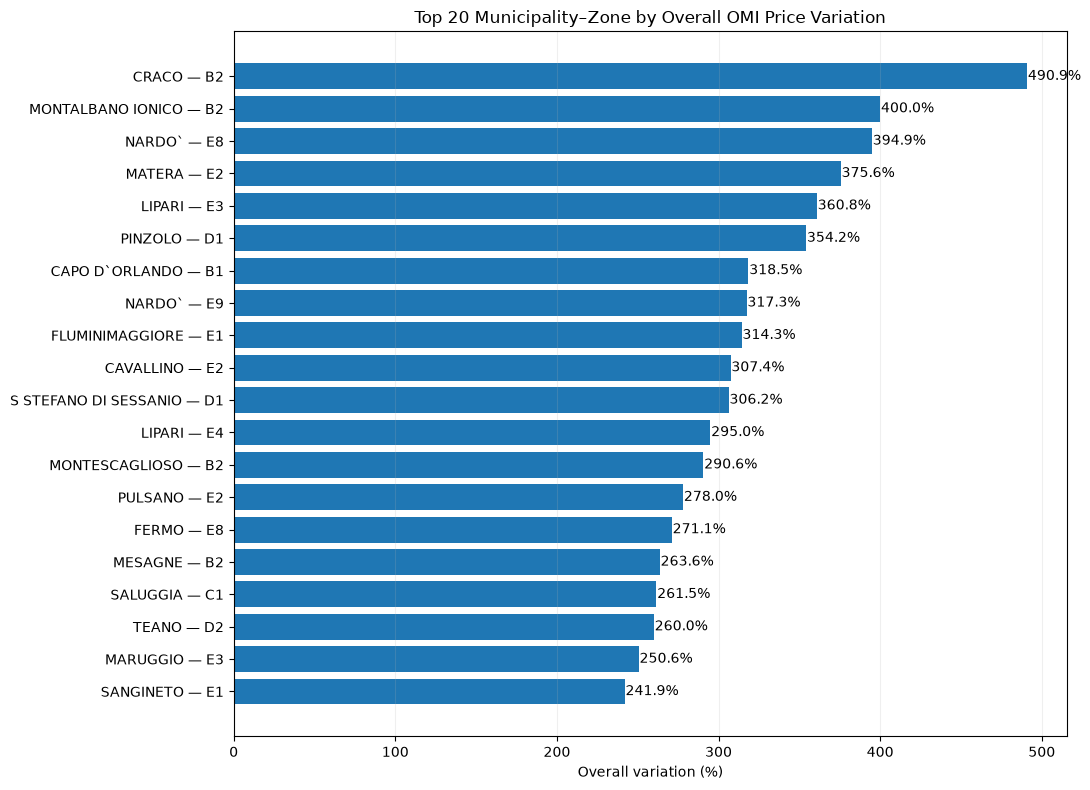

In [43]:
top_growth = (
    overall_change
    .nlargest(20, 'overall_change_pct')
    .reset_index()
    .sort_values('overall_change_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = top_growth['Comune_descrizione'] + ' — ' + top_growth['Zona']
bars = ax.barh(labels, top_growth['overall_change_pct'])

for bar, value in zip(bars, top_growth['overall_change_pct']):
    ax.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%', va='center')

ax.set_title('Top 20 Municipality–Zone by Overall OMI Price Variation')
ax.set_xlabel('Overall variation (%)')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.2)

fig.tight_layout()
plt.show()


#### 8.2.2 Top 20 Decliners

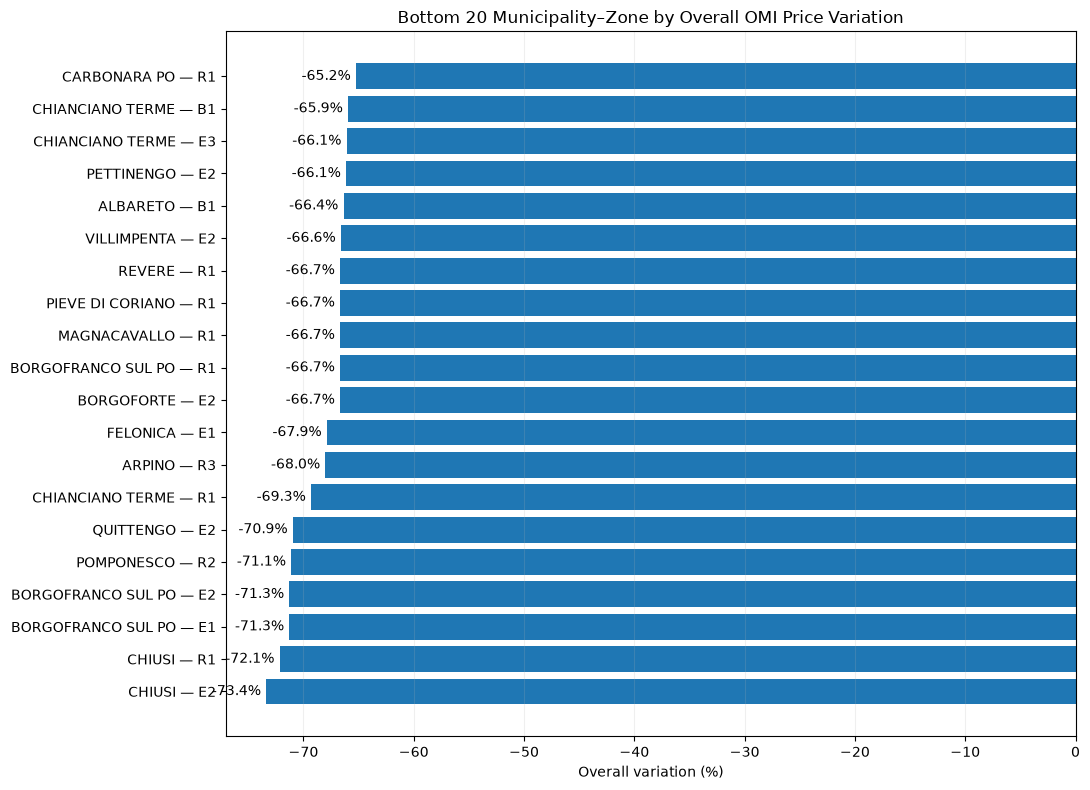

In [44]:
bottom_growth = (
    overall_change
    .nsmallest(20, 'overall_change_pct')
    .reset_index()
    .sort_values('overall_change_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = bottom_growth['Comune_descrizione'] + ' — ' + bottom_growth['Zona']
bars = ax.barh(labels, bottom_growth['overall_change_pct'])

for bar, value in zip(bars, bottom_growth['overall_change_pct']):
    ax.text(value - 0.5, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%', va='center', ha='right')

ax.set_title('Bottom 20 Municipality–Zone by Overall OMI Price Variation')
ax.set_xlabel('Overall variation (%)')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.2)

fig.tight_layout()
plt.show()


### 8.3 Comprehensive Growth Metrics

A single per-`(Comune_descrizione, Zona)` metrics table, combining level, growth,
volatility, drawdown and persistence statistics. Every later ranking and chart in this
section reads from this one table.


In [45]:
zone_growth_metrics = (
    national_zone_trend
    .groupby(['Comune_descrizione', 'Zona'])
    .agg(
        first_price=('median_compr_mid', 'first'),
        last_price=('median_compr_mid', 'last'),
        first_date=('reference_date', 'first'),
        last_date=('reference_date', 'last'),
        max_price=('median_compr_mid', 'max'),
        min_price=('median_compr_mid', 'min'),
        mean_growth_pct=('growth_pct', 'mean'),
        growth_volatility=('growth_pct', 'std'),
        positive_periods=('growth_pct', lambda x: (x > 0).sum()),
        negative_periods=('growth_pct', lambda x: (x < 0).sum()),
        max_semester_growth_pct=('growth_pct', 'max'),
        max_semester_decline_pct=('growth_pct', 'min'),
        max_drawdown_pct=('drawdown_pct', 'min'),
        total_observations=('observations', 'sum'),
        n_periods=('reference_date', 'count')
    )
)

# Coverage, in years
zone_growth_metrics['coverage_years'] = (
    (zone_growth_metrics['last_date'] - zone_growth_metrics['first_date']).dt.days / 365.25
)

# Overall price variation
zone_growth_metrics['overall_change_pct'] = (
    (zone_growth_metrics['last_price'] / zone_growth_metrics['first_price']) - 1
) * 100

zone_growth_metrics['absolute_change_eur_m2'] = (
    zone_growth_metrics['last_price'] - zone_growth_metrics['first_price']
)

# CAGR — only defined when coverage_years > 0 (i.e. more than one distinct date)
zone_growth_metrics['cagr_pct'] = np.where(
    zone_growth_metrics['coverage_years'] > 0,
    (
        (zone_growth_metrics['last_price'] / zone_growth_metrics['first_price'])
        ** (1 / zone_growth_metrics['coverage_years'].replace(0, np.nan)) - 1
    ) * 100,
    np.nan
)

# Latest year-over-year growth
zone_growth_metrics['latest_yoy_growth_pct'] = (
    national_zone_trend
    .sort_values('reference_date')
    .groupby(['Comune_descrizione', 'Zona'])['yoy_growth_pct']
    .last()
)

# Latest drawdown from the historical maximum
zone_growth_metrics['latest_drawdown_pct'] = (
    national_zone_trend
    .sort_values('reference_date')
    .groupby(['Comune_descrizione', 'Zona'])['drawdown_pct']
    .last()
)

# Share of semesters with positive growth (undefined, not zero, when there is no
# growth observation at all)
total_growth_periods = zone_growth_metrics['positive_periods'] + zone_growth_metrics['negative_periods']

zone_growth_metrics['positive_growth_share_pct'] = np.where(
    total_growth_periods > 0,
    (zone_growth_metrics['positive_periods'] / total_growth_periods) * 100,
    np.nan
)

# Price range
zone_growth_metrics['price_range_eur_m2'] = zone_growth_metrics['max_price'] - zone_growth_metrics['min_price']
zone_growth_metrics['price_range_pct'] = (
    (zone_growth_metrics['max_price'] / zone_growth_metrics['min_price']) - 1
) * 100

zone_growth_metrics = zone_growth_metrics.sort_values('overall_change_pct', ascending=False)

# Subset with enough history for growth-rate rankings (CAGR, volatility, persistence, YoY)
zone_growth_eligible = zone_growth_metrics[zone_growth_metrics['n_periods'] >= MIN_PERIODS]

print(f"Municipality–zone series: {len(zone_growth_metrics):,} total, {len(zone_growth_eligible):,} with >= {MIN_PERIODS} semesters of history")

display(
    zone_growth_metrics[[
        'first_price', 'last_price', 'overall_change_pct', 'cagr_pct',
        'latest_yoy_growth_pct', 'mean_growth_pct', 'growth_volatility',
        'positive_growth_share_pct', 'max_drawdown_pct', 'n_periods', 'coverage_years'
    ]].head(20).style.format({
        'first_price': '€{:,.0f}',
        'last_price': '€{:,.0f}',
        'overall_change_pct': '{:.1f}%',
        'cagr_pct': '{:.1f}%',
        'latest_yoy_growth_pct': '{:.1f}%',
        'mean_growth_pct': '{:.1f}%',
        'growth_volatility': '{:.1f}%',
        'positive_growth_share_pct': '{:.1f}%',
        'max_drawdown_pct': '{:.1f}%',
        'coverage_years': '{:.1f}'
    })
)


Municipality–zone series: 39,870 total, 35,784 with >= 4 semesters of history


,,first_price,last_price,overall_change_pct,cagr_pct,latest_yoy_growth_pct,mean_growth_pct,growth_volatility,positive_growth_share_pct,max_drawdown_pct,n_periods,coverage_years
Comune_descrizione,Zona,,,,,,,,,,,
CRACO,B2,€33,€195,490.9%,8.6%,0.0%,6.7%,31.1%,100.0%,0.0%,44,21.5
MONTALBANO IONICO,B2,€69,€345,400.0%,7.8%,0.0%,9.3%,60.7%,100.0%,0.0%,44,21.5
NARDO`,E8,€245,"€1,212",394.9%,7.7%,2.3%,15.8%,76.6%,72.7%,-5.3%,25,21.5
MATERA,E2,€287,"€1,365",375.6%,7.5%,0.0%,4.8%,18.3%,80.0%,-18.3%,44,21.5
LIPARI,E3,€415,"€1,912",360.8%,7.4%,11.7%,4.6%,17.1%,81.2%,-12.3%,44,21.5
PINZOLO,D1,€600,"€2,725",354.2%,65.7%,0.0%,51.2%,118.1%,100.0%,0.0%,7,3.0
CAPO D`ORLANDO,B1,€460,"€1,925",318.5%,6.9%,10.0%,4.1%,13.8%,73.1%,-17.2%,44,21.5
NARDO`,E9,€245,"€1,022",317.3%,6.9%,0.7%,14.6%,73.7%,61.5%,-14.6%,25,21.5
FLUMINIMAGGIORE,E1,€350,"€1,450",314.3%,6.8%,0.0%,6.7%,42.2%,60.0%,-9.4%,44,21.5


#### 8.3.1 Rankings (restricted to series with ≥ `MIN_PERIODS` semesters)

In [46]:
zone_growth_eligible.nlargest(20, 'cagr_pct')[[
    'first_price', 'last_price', 'cagr_pct', 'coverage_years', 'n_periods'
]]


,,first_price,last_price,cagr_pct,coverage_years,n_periods
Comune_descrizione,Zona,,,,,
PINZOLO,D1,600.0,2725.0,65.661581,2.997947,7
VAIRANO PATENORA,B2,465.0,1000.0,46.685576,1.998631,5
PIZZO,C1,525.0,867.5,39.671830,1.503080,4
ISILI,E2,270.0,600.0,37.588520,2.502396,6
ANAGNI,B2,520.0,825.0,35.943954,1.503080,4
CASAGIOVE,B4,740.0,1150.0,34.301981,1.494867,4
BARBARANO VICENTINO,C2,725.0,1300.0,33.880073,2.001369,5
ELINI,E2,235.0,485.0,33.582342,2.502396,6
OLLOLAI,E2,235.0,485.0,33.582342,2.502396,6


In [47]:
zone_growth_eligible.nlargest(20, 'growth_volatility')[[
    'mean_growth_pct', 'growth_volatility', 'n_periods'
]]


mean_growth_pct  growth_volatility  n_periods
Comune_descrizione  Zona                                               
PINZOLO             D1          51.231560         118.063127          7
NARDO`              E8          15.831710          76.636575         25
                    E9          14.642162          73.659039         25
SALUGGIA            C1          15.279307          68.978459         20
MONTALBANO IONICO   B2           9.261915          60.666345         44
BARBARANO VICENTINO C2          23.159443          55.465623          5
ISILI               E2          24.444444          54.659439          6
SALUGGIA            D1          11.793158          52.418545         20
FERMO               E8           7.918340          52.158270         41
LIZZANELLO          E2          10.123296          49.838925         25
ELINI               E2          21.276596          47.575914          6
OLLOLAI             E2          21.276596          47.575914          6
ORANI               E2          21.276596          47.575914          6
DESULO              E2          21.276596          47.575914          6
LIPARI              E4           7.099397          46.934883         44
AMANTEA             D1          11.820360          45.642713         18
PRAROLO             E1           9.979876          44.602909         20
OVODDA              E2          19.591837          43.808679          6
OROTELLI            E2          19.591837          43.808679          6
OLZAI               E2          19.591837          43.808679          6

In [48]:
zone_growth_eligible.nsmallest(20, 'max_drawdown_pct')[[
    'max_price', 'min_price', 'max_drawdown_pct', 'n_periods'
]]


max_price  min_price  max_drawdown_pct  n_periods
Comune_descrizione     Zona                                                   
CHIUSI                 E2       1600.0     426.25        -73.359375         44
BORGOFRANCO SUL PO     R1       1087.5     300.00        -72.413793         22
MAGNACAVALLO           R1       1087.5     300.00        -72.413793         36
CHIUSI                 R1       1467.5     408.75        -72.146508         44
PIEVE DI CORIANO       R1       1087.5     312.50        -71.264368         20
REVERE                 R1       1087.5     312.50        -71.264368         20
BORGOFRANCO SUL PO     E2       1087.5     312.50        -71.264368         12
                       E1       1087.5     312.50        -71.264368         12
POMPONESCO             R2        865.0     250.00        -71.098266         12
QUITTENGO              E2        895.0     260.00        -70.949721         20
QUINGENTOLE            R1       1042.5     312.50        -70.023981         36
SAN GIACOMO D SEGNATE  R1       1042.5     312.50        -70.023981         36
SAN GIOVANNI DEL DOSSO R1       1042.5     312.50        -70.023981         36
VILLA POMA             R1       1042.5     312.50        -70.023981         20
SCHIVENOGLIA           R1       1042.5     312.50        -70.023981         36
CARBONARA PO           R1       1042.5     312.50        -70.023981         22
SAN TEODORO            B1       1395.0     421.25        -69.802867         44
POGGIO RUSCO           R1       1025.0     312.50        -69.512195         36
CHIANCIANO TERME       R1       1787.5     548.75        -69.300699         44
FABRIANO               B1       1785.0     550.00        -69.187675         44

In [49]:
zone_growth_eligible.nlargest(20, 'positive_growth_share_pct')[[
    'positive_periods', 'negative_periods', 'positive_growth_share_pct', 'n_periods'
]]


,,positive_periods,negative_periods,positive_growth_share_pct,n_periods
Comune_descrizione,Zona,,,,
CRACO,B2,4,0,100.0,44
MONTALBANO IONICO,B2,3,0,100.0,44
PINZOLO,D1,3,0,100.0,7
MONTESCAGLIOSO,B2,3,0,100.0,44
MESAGNE,B2,5,0,100.0,44
BADOLATO,E1,2,0,100.0,20
SANTA MARINA SALINA,D1,3,0,100.0,20
IGLESIAS,E1,7,0,100.0,20
MALFA,E1,3,0,100.0,24


In [50]:
zone_growth_eligible.nlargest(20, 'latest_yoy_growth_pct')[[
    'last_price', 'latest_yoy_growth_pct', 'n_periods'
]]


last_price  latest_yoy_growth_pct  n_periods
Comune_descrizione Zona                                              
SAN NAZARIO        D1        1250.0             125.225225         19
                   C1        1250.0             125.225225         20
TONEZZA DEL CIMONE D1        1250.0             125.225225         20
CISMON DEL GRAPPA  C1        1250.0             125.225225         20
ROTZO              D1        1450.0             124.806202         20
CHIAMPO            D1        1400.0             122.664016         20
SAN PIER NICETO    D1         812.5             122.602740         21
CISMON DEL GRAPPA  D1        1200.0             121.198157         20
VALSTAGNA          C1        1250.0             119.298246         20
BREGANZE           C1        1450.0             118.045113         20
TRISSINO           D2        1350.0             116.432866         19
SOLAGNA            D1        1200.0             116.216216         20
CHIAMPO            D3        1400.0             113.740458         20
                   D2        1400.0             113.740458         20
ROCCAMASSIMA       E1        1025.0             111.340206         20
VALSTAGNA          D1        1200.0             110.526316         19
SARCEDO            D2        1350.0             109.302326         19
ELINI              E2         485.0             106.382979          6
OLLOLAI            E2         485.0             106.382979          6
ORANI              E2         485.0             106.382979          6

> **Interpretation.** These five leaderboards separate different notions of
> "performance": highest compounded annual growth (`cagr_pct`), most erratic growth
> (`growth_volatility`), smallest peak-to-trough correction (`max_drawdown_pct`), most
> consistent upward movement (`positive_growth_share_pct`), and strongest most-recent
> momentum (`latest_yoy_growth_pct`). A zone that ranks highly on CAGR but also on
> volatility is a high-growth, high-risk area; one that ranks highly on both CAGR and
> `positive_growth_share_pct` with low volatility is a steadier long-term performer.


### 8.4 Risk–Return Profile

Plotting CAGR against growth volatility for every eligible municipality-zone gives a
risk-return view of the market, analogous to a financial risk-return scatter plot.


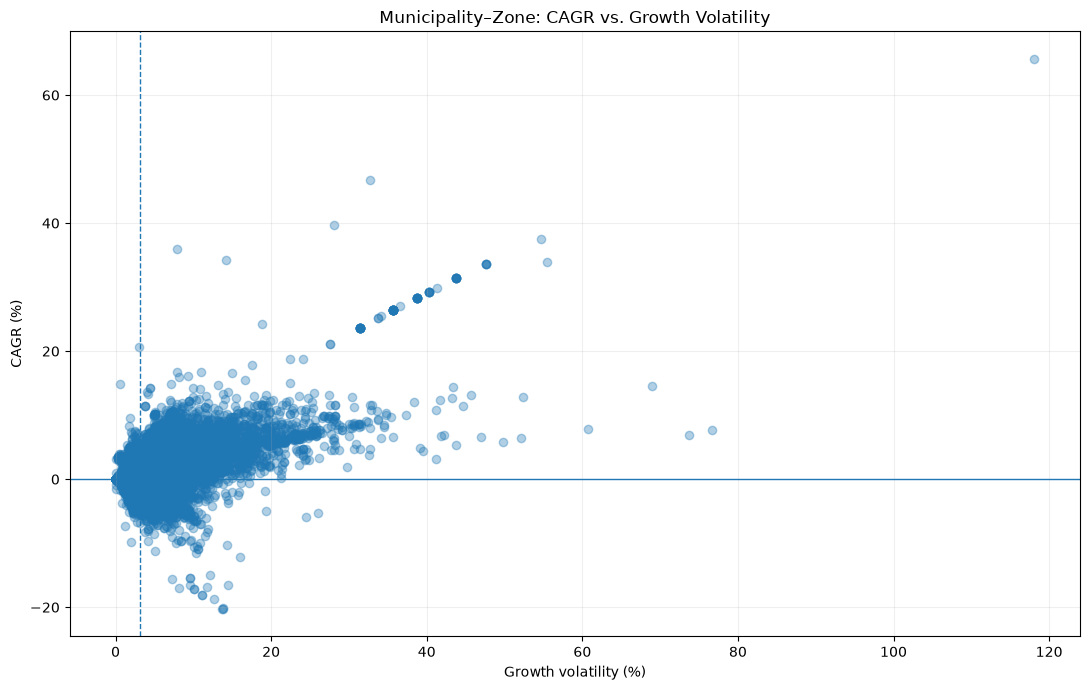

In [51]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(zone_growth_eligible['growth_volatility'], zone_growth_eligible['cagr_pct'], alpha=0.35)

ax.axhline(0, linewidth=1)
ax.axvline(zone_growth_eligible['growth_volatility'].median(), linewidth=1, linestyle='--')

ax.set_title('Municipality–Zone: CAGR vs. Growth Volatility')
ax.set_xlabel('Growth volatility (%)')
ax.set_ylabel('CAGR (%)')
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()


> **Interpretation.** The horizontal line at CAGR = 0% separates appreciating from
> depreciating zones; the vertical dashed line marks the median volatility. Points in
> the upper-left quadrant (positive CAGR, below-median volatility) are the most
> attractive combination of growth and stability; points in the lower-right quadrant
> combine price decline with high volatility.


### 8.5 National Price Distribution and Dispersion

Beyond central tendency, tracking the P10–P90 spread of the median-zone-price
distribution over time shows whether the market is becoming more or less homogeneous.


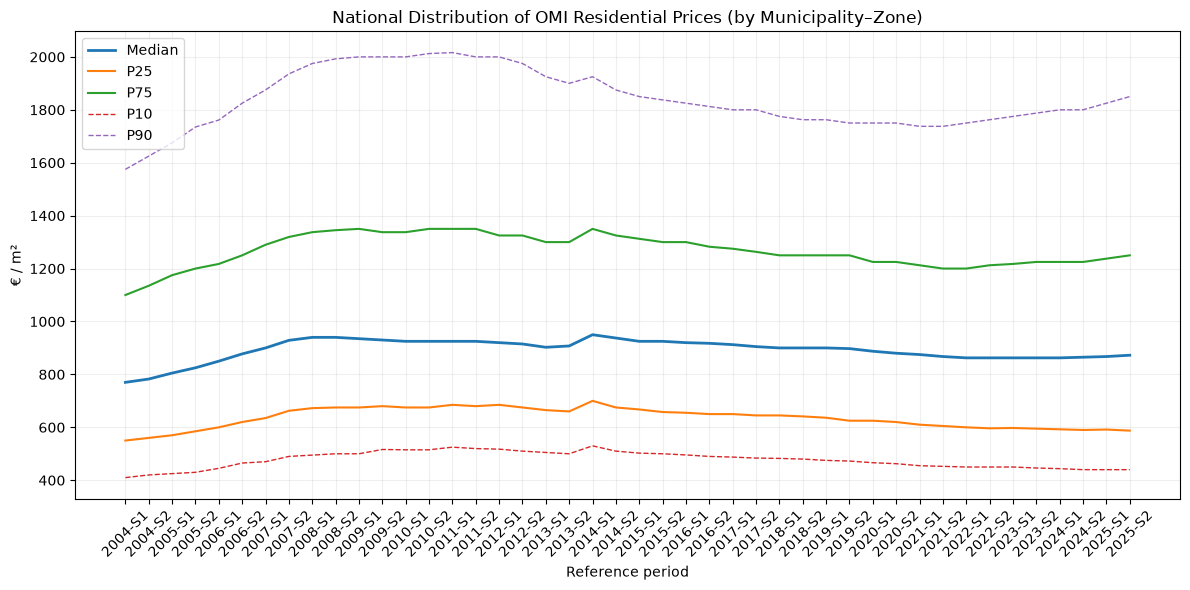

In [52]:
price_distribution = (
    national_zone_trend
    .groupby('period')['median_compr_mid']
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
    .unstack()
    .reset_index()
)

price_distribution.columns = ['period', 'p10', 'p25', 'p50', 'p75', 'p90']

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(price_distribution['period'], price_distribution['p50'], linewidth=2, label='Median')
ax.plot(price_distribution['period'], price_distribution['p25'], linewidth=1.5, label='P25')
ax.plot(price_distribution['period'], price_distribution['p75'], linewidth=1.5, label='P75')
ax.plot(price_distribution['period'], price_distribution['p10'], linewidth=1, linestyle='--', label='P10')
ax.plot(price_distribution['period'], price_distribution['p90'], linewidth=1, linestyle='--', label='P90')

ax.set_title('National Distribution of OMI Residential Prices (by Municipality–Zone)')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
ax.legend()
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()


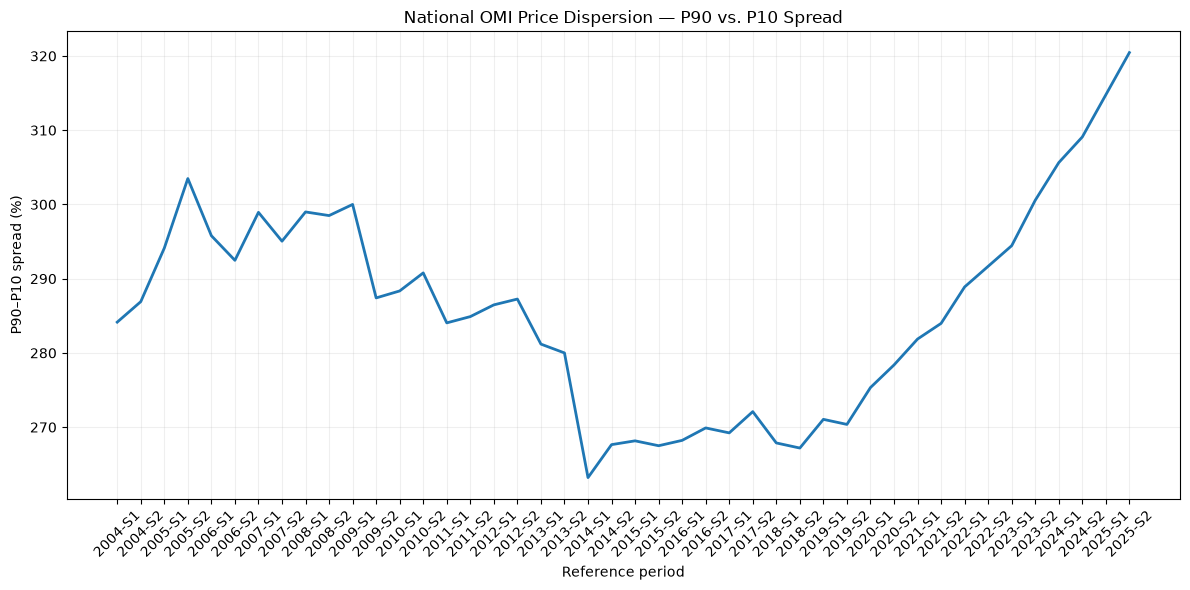

In [53]:
price_dispersion = price_distribution.assign(
    p90_p10_spread_eur_m2=lambda x: x['p90'] - x['p10'],
    p75_p25_spread_eur_m2=lambda x: x['p75'] - x['p25'],
    p90_p10_spread_pct=lambda x: (x['p90'] / x['p10'] - 1) * 100
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(price_dispersion['period'], price_dispersion['p90_p10_spread_pct'], linewidth=2)

ax.set_title('National OMI Price Dispersion — P90 vs. P10 Spread')
ax.set_xlabel('Reference period')
ax.set_ylabel('P90–P10 spread (%)')
ax.grid(alpha=0.2)
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()


> **Interpretation.** A widening P90–P10 spread over time means the gap between
> expensive and cheap zones is growing — the market is polarising. A narrowing spread
> means prices are converging across zones.


### 8.6 Intra-Municipal Zone Price Spread

For each municipality, the gap between its most and least expensive OMI zone quantifies
how much internal heterogeneity a single municipality-level average hides.


In [54]:
municipality_zone_spread = (
    national_zone_trend
    .groupby(['reference_date', 'Comune_descrizione'])
    .agg(
        max_price=('median_compr_mid', 'max'),
        min_price=('median_compr_mid', 'min'),
        median_price=('median_compr_mid', 'median'),
        n_zones=('Zona', 'nunique')
    )
    .reset_index()
)

municipality_zone_spread['spread_eur_m2'] = (
    municipality_zone_spread['max_price'] - municipality_zone_spread['min_price']
)

municipality_zone_spread['spread_pct'] = (
    (municipality_zone_spread['max_price'] / municipality_zone_spread['min_price']) - 1
) * 100

latest_date = municipality_zone_spread['reference_date'].max()

# Restrict to municipalities with more than one OMI zone: a single-zone municipality has
# a spread of 0% by construction and is not informative here.
latest_spread = (
    municipality_zone_spread[
        municipality_zone_spread['reference_date'].eq(latest_date)
        & municipality_zone_spread['n_zones'].gt(1)
    ]
    .sort_values('spread_pct', ascending=False)
)

display(latest_spread.head(20))


,reference_date,Comune_descrizione,max_price,min_price,median_price,n_zones,spread_eur_m2,spread_pct
346882,2025-12-31,COURMAYEUR,10000.0,1187.50,7125.00,6,8812.50,742.105263
350252,2025-12-31,ROMA,9100.0,1100.00,2587.50,212,8000.00,727.272727
350782,2025-12-31,SAN TEODORO,3387.5,421.25,2500.00,7,2966.25,704.154303
349622,2025-12-31,PINZOLO,9500.0,1300.00,5275.00,9,8200.00,630.769231
349821,2025-12-31,PORTOFINO,16525.0,2350.00,8350.00,4,14175.00,603.191489
348247,2025-12-31,MARATEA,1775.0,275.00,1040.00,11,1500.00,545.454545
351180,2025-12-31,SESTRI LEVANTE,8075.0,1300.00,3443.75,10,6775.00,521.153846
345506,2025-12-31,CABRAS,2300.0,400.00,1133.75,4,1900.00,475.000000
349920,2025-12-31,PRE` SAINT DIDIER,6000.0,1062.50,2806.25,4,4937.50,464.705882
351461,2025-12-31,TAORMINA,4300.0,785.00,2900.00,5,3515.00,447.770701


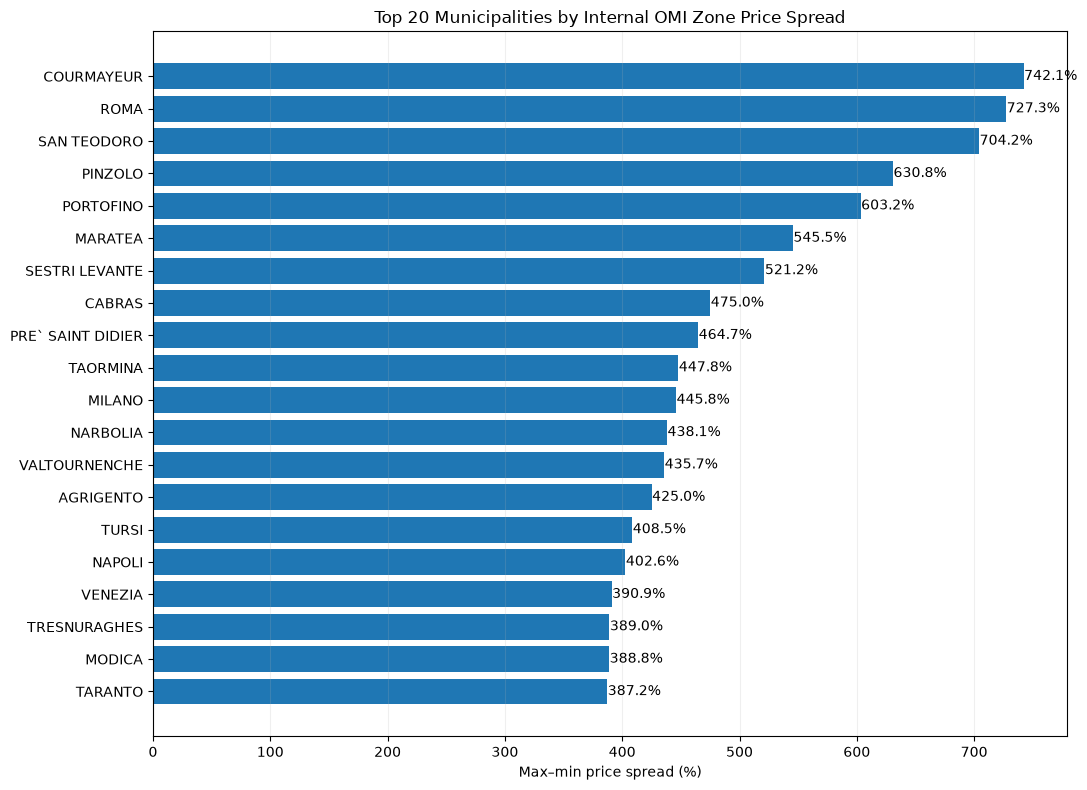

In [55]:
top_spread = latest_spread.head(20).sort_values('spread_pct')

fig, ax = plt.subplots(figsize=(11, 8))

labels = top_spread['Comune_descrizione']
bars = ax.barh(labels, top_spread['spread_pct'])

for bar, value in zip(bars, top_spread['spread_pct']):
    ax.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%', va='center')

ax.set_title('Top 20 Municipalities by Internal OMI Zone Price Spread')
ax.set_xlabel('Max–min price spread (%)')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.2)

fig.tight_layout()
plt.show()


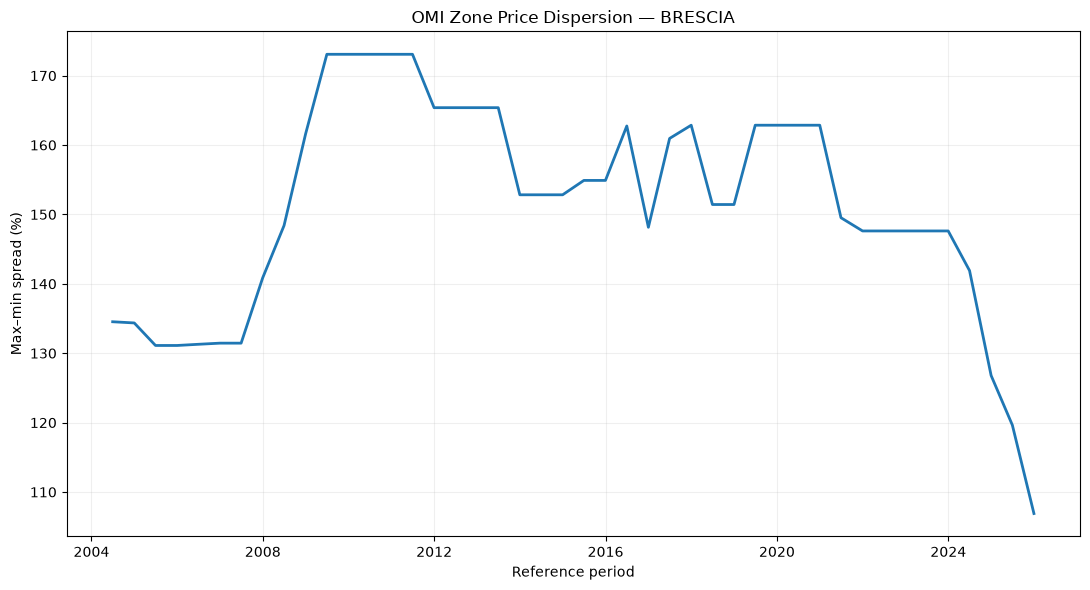

In [56]:
selected_municipality = 'BRESCIA'

municipality_history = municipality_zone_spread[
    municipality_zone_spread['Comune_descrizione'].eq(selected_municipality)
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(municipality_history['reference_date'], municipality_history['spread_pct'], linewidth=2)

ax.set_title(f'OMI Zone Price Dispersion — {selected_municipality}')
ax.set_xlabel('Reference period')
ax.set_ylabel('Max–min spread (%)')
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()


> **Interpretation.** Municipalities at the top of this ranking are ones where "the
> average price" is a particularly poor summary — the best and worst zones diverge
> sharply, typically driven by a historic centre commanding a large premium over
> peripheral zones.


### 8.7 Growth Persistence

`positive_growth_share_pct` measures how consistently a municipality-zone's price has
grown, rather than how much. It complements CAGR: a zone can have a high CAGR driven by
one or two strong semesters, or a lower CAGR built from many small, consistent gains.


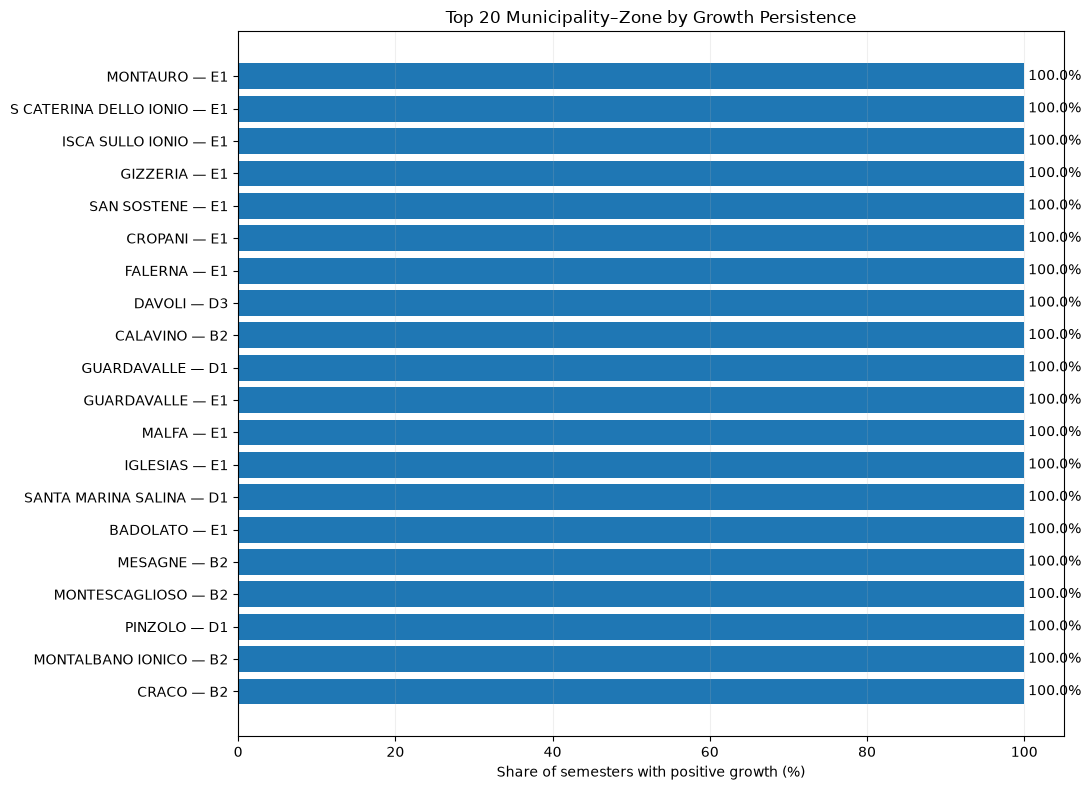

In [57]:
top_persistence = (
    zone_growth_eligible
    .nlargest(20, 'positive_growth_share_pct')
    .reset_index()
    .sort_values('positive_growth_share_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = top_persistence['Comune_descrizione'] + ' — ' + top_persistence['Zona']
bars = ax.barh(labels, top_persistence['positive_growth_share_pct'])

for bar, value in zip(bars, top_persistence['positive_growth_share_pct']):
    ax.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%', va='center')

ax.set_title('Top 20 Municipality–Zone by Growth Persistence')
ax.set_xlabel('Share of semesters with positive growth (%)')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.2)

fig.tight_layout()
plt.show()


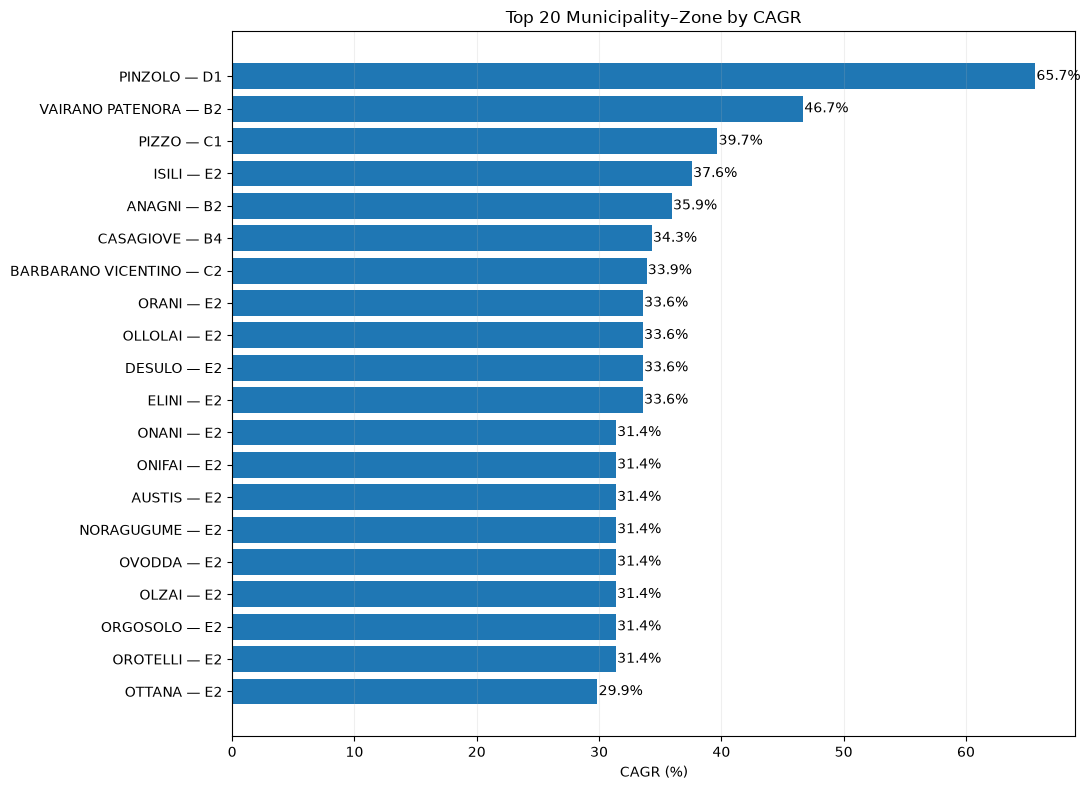

In [58]:
top_cagr = (
    zone_growth_eligible
    .nlargest(20, 'cagr_pct')
    .reset_index()
    .sort_values('cagr_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = top_cagr['Comune_descrizione'] + ' — ' + top_cagr['Zona']
bars = ax.barh(labels, top_cagr['cagr_pct'])

for bar, value in zip(bars, top_cagr['cagr_pct']):
    ax.text(value + 0.1, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%', va='center')

ax.set_title('Top 20 Municipality–Zone by CAGR')
ax.set_xlabel('CAGR (%)')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.2)

fig.tight_layout()
plt.show()


> **Interpretation.** Comparing this section's persistence leaderboard with the CAGR
> leaderboard in 8.3.1 shows whether the fastest-growing zones are also the most
> consistent ones, or whether high headline growth is concentrated in a few volatile
> semesters.
